In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.special import expit as sigmoid
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from dataclasses import dataclass
from typing import Optional
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
colors = sns.color_palette("muted")

# ── Config ────────────────────────────────────────────────────────────────
DATA_PATH = "SharedResponses.csv"
CHAR_COLS = [
    "Man", "Woman", "Pregnant", "Stroller", "OldMan", "OldWoman",
    "Boy", "Girl", "Homeless", "LargeWoman", "LargeMan", "Criminal",
    "MaleExecutive", "FemaleExecutive", "FemaleAthlete", "MaleAthlete",
    "FemaleDoctor", "MaleDoctor", "Dog", "Cat",
]
KEEP_COLS = ["ResponseID", "UserID", "Saved"] + CHAR_COLS
TOP_N_USERS = 5000

## 1. Load data and find top users

Read only the columns we need. Count responses per user, keep the top 5000 most active users (more responses → more stable preference estimates, less noise from random clickers).

In [2]:
import os

FILTERED_PATH = "top_users_filtered.csv"

if os.path.exists(FILTERED_PATH):
    print(f"Loading cached filtered data from {FILTERED_PATH} ...")
    df_filtered = pd.read_csv(FILTERED_PATH)
    print(f"Loaded {len(df_filtered):,} rows from {df_filtered['UserID'].nunique():,} users")
    print("Skipping Passes 1 & 2 and bot filter — delete the CSV to re-run them.")
else:
    df_filtered = None  # will be built by the cells below
    print(f"{FILTERED_PATH} not found — running full pipeline...")

Loading cached filtered data from top_users_filtered.csv ...
Loaded 11,667,348 rows from 5,000 users
Skipping Passes 1 & 2 and bot filter — delete the CSV to re-run them.


In [3]:
if df_filtered is None:
    # ── Pass 1: count responses per user (chunked to avoid OOM) ───────────────
    print("Pass 1: counting responses per user...")
    user_counts = pd.Series(dtype=int)
    for chunk in pd.read_csv(DATA_PATH, usecols=["UserID"], chunksize=5_000_000):
        counts = chunk["UserID"].value_counts()
        user_counts = user_counts.add(counts, fill_value=0).astype(int)
        print(f"  processed {len(user_counts):,} unique users so far...")

    print(f"\nTotal unique users: {len(user_counts):,}")
    print(f"Response count distribution:")
    print(user_counts.describe())

    # ── Select top N users ────────────────────────────────────────────────────
    top_users = set(user_counts.nlargest(TOP_N_USERS).index)
    min_responses = user_counts.nlargest(TOP_N_USERS).min()
    print(f"\nTop {TOP_N_USERS} users have ≥ {min_responses} responses each")
else:
    print("Skipping Pass 1 (loaded from cache).")

Skipping Pass 1 (loaded from cache).


In [4]:
if df_filtered is None:
    # ── Pass 2: load only top users' data ─────────────────────────────────────
    print("Pass 2: loading data for top users...")
    chunks = []
    for chunk in pd.read_csv(DATA_PATH, usecols=KEEP_COLS, chunksize=5_000_000):
        mask = chunk["UserID"].isin(top_users)
        chunks.append(chunk[mask])
        print(f"  kept {mask.sum():,} / {len(chunk):,} rows")

    df = pd.concat(chunks, ignore_index=True)

    # Coerce character columns to numeric (some rows have non-numeric entries)
    for col in CHAR_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    n_bad = df[CHAR_COLS].isna().any(axis=1).sum()
    if n_bad > 0:
        print(f"  Dropped {n_bad:,} rows with non-numeric character values")
        df = df.dropna(subset=CHAR_COLS).reset_index(drop=True)

    print(f"\nFinal dataset: {len(df):,} rows from {df['UserID'].nunique():,} users")
    print(f"Responses per user: mean={len(df)/df['UserID'].nunique():.0f}, "
          f"min={df.groupby('UserID').size().min()}, "
          f"max={df.groupby('UserID').size().max()}")
else:
    print("Skipping Pass 2 (loaded from cache).")

Skipping Pass 2 (loaded from cache).


In [5]:
BOT_STD_THRESHOLD = 0.05
FILTERED_PATH = "top_users_filtered.csv"

if df_filtered is None:
    # ── Bot / overly-consistent user filter ───────────────────────────────────
    # Flag users whose Saved column has near-zero variance (always pick same option).
    user_saved_std = df.groupby("UserID")["Saved"].std()
    bot_users = set(user_saved_std[user_saved_std < BOT_STD_THRESHOLD].index)

    print(f"Users flagged as bots (std < {BOT_STD_THRESHOLD}): {len(bot_users):,} "
          f"/ {df['UserID'].nunique():,} ({100*len(bot_users)/df['UserID'].nunique():.1f}%)")

    df_filtered = df[~df["UserID"].isin(bot_users)].reset_index(drop=True)
    print(f"Rows after bot removal: {len(df_filtered):,} "
          f"(from {df_filtered['UserID'].nunique():,} users)")

    df_filtered.to_csv(FILTERED_PATH, index=False)
    print(f"\nSaved filtered data to {FILTERED_PATH}")
else:
    print("Skipping bot filter (loaded from cache).")

Skipping bot filter (loaded from cache).


Response count percentiles:
  p 50.0: 974
  p 75.0: 1,853
  p 90.0: 4,388
  p 95.0: 7,819
  p 99.0: 23,988
  p 99.5: 34,151
  p 99.9: 65,836
  p100.0: 131,571

  mean:   2,333.5
  median: 974
  max:    131,571


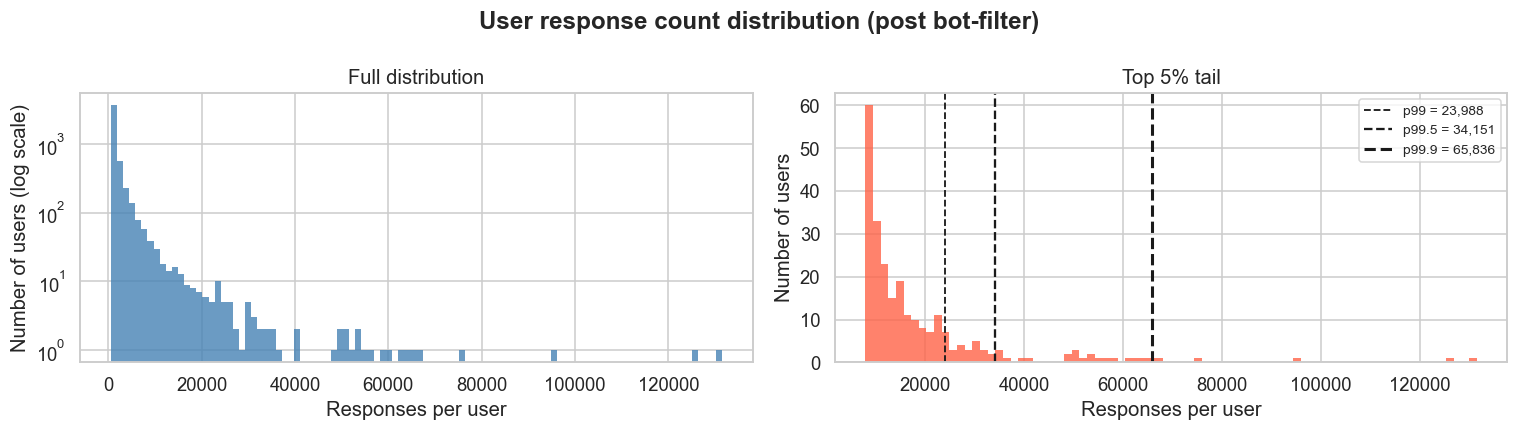

In [6]:
# ── Response count histogram ───────────────────────────────────────────────
resp_counts = df_filtered.groupby("UserID").size().sort_values(ascending=False)

pcts = [50, 75, 90, 95, 99, 99.5, 99.9, 100]
print("Response count percentiles:")
for p in pcts:
    print(f"  p{p:5.1f}: {np.percentile(resp_counts, p):,.0f}")
print(f"\n  mean:   {resp_counts.mean():,.1f}")
print(f"  median: {resp_counts.median():,.0f}")
print(f"  max:    {resp_counts.max():,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full distribution (log y)
axes[0].hist(resp_counts, bins=100, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].set_yscale("log")
axes[0].set_xlabel("Responses per user")
axes[0].set_ylabel("Number of users (log scale)")
axes[0].set_title("Full distribution")

# Right: zoom into the long tail (top 5%)
tail_thresh = np.percentile(resp_counts, 95)
axes[1].hist(resp_counts[resp_counts >= tail_thresh], bins=80,
             color="tomato", edgecolor="none", alpha=0.8)
axes[1].set_xlabel("Responses per user")
axes[1].set_ylabel("Number of users")
axes[1].set_title("Top 5% tail")
for p, lw in [(99, 1.2), (99.5, 1.5), (99.9, 2.0)]:
    v = np.percentile(resp_counts, p)
    axes[1].axvline(v, color="k", linewidth=lw, linestyle="--",
                    label=f"p{p} = {v:,.0f}")
axes[1].legend(fontsize=9)

plt.suptitle("User response count distribution (post bot-filter)", fontweight="bold")
plt.tight_layout()
plt.show()

## 1b. Alternative pool: random sample of 5 000 "mid-activity" users (100–500 responses)

Same pipeline as above, but instead of the top 5 000 by response count we draw a uniform random sample of users with 100–500 responses. This lets us compare conclusions across two very different populations: a **power-user pool** (many observations per person, potentially unrepresentative) vs a **mid-activity pool** (moderate engagement, closer to a typical active user).

In [7]:
MID_FILTERED_PATH = "mid_users_filtered.csv"
MID_N_USERS       = 5_000
MID_MIN_RESP      = 100
MID_MAX_RESP      = 500
MID_SEED          = 42

if os.path.exists(MID_FILTERED_PATH):
    print(f"Loading cached mid-activity pool from {MID_FILTERED_PATH} ...")
    df_mid = pd.read_csv(MID_FILTERED_PATH)
    print(f"Loaded {len(df_mid):,} rows from {df_mid['UserID'].nunique():,} users")
else:
    # ── Need full user_counts; recompute if Pass 1 was skipped ───────────
    try:
        user_counts
        print("Using user_counts from Pass 1.")
    except NameError:
        print("user_counts not in scope — recomputing from raw CSV...")
        user_counts = pd.Series(dtype=int)
        for chunk in pd.read_csv(DATA_PATH, usecols=["UserID"], chunksize=5_000_000):
            counts = chunk["UserID"].value_counts()
            user_counts = user_counts.add(counts, fill_value=0).astype(int)
            print(f"  {len(user_counts):,} unique users so far...")
        print(f"Done. {len(user_counts):,} total unique users.")

    # ── Sample MID_N_USERS users with response count in [MID_MIN, MID_MAX] ─
    eligible = user_counts[(user_counts >= MID_MIN_RESP) & (user_counts <= MID_MAX_RESP)]
    print(f"\nEligible users ({MID_MIN_RESP}–{MID_MAX_RESP} responses): {len(eligible):,}")

    if len(eligible) < MID_N_USERS:
        print(f"  WARNING: only {len(eligible):,} eligible users — using all of them")
        mid_users = set(eligible.index)
    else:
        rng = np.random.default_rng(MID_SEED)
        sampled_ids = rng.choice(eligible.index, size=MID_N_USERS, replace=False)
        mid_users = set(sampled_ids)
    print(f"Sampled {len(mid_users):,} users")

    # ── Load their rows from the raw CSV ──────────────────────────────────
    print("\nLoading mid-activity users' rows from raw CSV...")
    chunks = []
    for chunk in pd.read_csv(DATA_PATH, usecols=KEEP_COLS, chunksize=5_000_000):
        mask = chunk["UserID"].isin(mid_users)
        if mask.any():
            chunks.append(chunk[mask])

    df_mid_raw = pd.concat(chunks, ignore_index=True)
    for col in CHAR_COLS:
        df_mid_raw[col] = pd.to_numeric(df_mid_raw[col], errors="coerce")
    df_mid_raw = df_mid_raw.dropna(subset=CHAR_COLS).reset_index(drop=True)
    print(f"Loaded {len(df_mid_raw):,} rows from {df_mid_raw['UserID'].nunique():,} users")

    # ── Same bot filter ───────────────────────────────────────────────────
    mid_saved_std = df_mid_raw.groupby("UserID")["Saved"].std()
    mid_bots = set(mid_saved_std[mid_saved_std < BOT_STD_THRESHOLD].index)
    print(f"Bot users removed: {len(mid_bots):,}")

    df_mid = df_mid_raw[~df_mid_raw["UserID"].isin(mid_bots)].reset_index(drop=True)
    print(f"Final mid-activity pool: {len(df_mid):,} rows, {df_mid['UserID'].nunique():,} users")

    df_mid.to_csv(MID_FILTERED_PATH, index=False)
    print(f"\nSaved to {MID_FILTERED_PATH}")

# Quick comparison
print("\n── Pool comparison ──────────────────────────────────────────────")
for label, d in [("Power-user pool (top 5k)", df_filtered), ("Mid-activity pool (100–500)", df_mid)]:
    rc = d.groupby("UserID").size()
    print(f"  {label}: {d['UserID'].nunique():,} users | "
          f"responses/user: mean={rc.mean():.0f}, median={rc.median():.0f}, "
          f"min={rc.min()}, max={rc.max()}")

Loading cached mid-activity pool from mid_users_filtered.csv ...
Loaded 906,167 rows from 5,000 users

── Pool comparison ──────────────────────────────────────────────
  Power-user pool (top 5k): 5,000 users | responses/user: mean=2333, median=974, min=492, max=131571
  Mid-activity pool (100–500): 5,000 users | responses/user: mean=181, median=146, min=100, max=500


## 2. Build preference profiles

For each ResponseID, compute α_z = chars(Saved=1) − chars(Saved=0). This is the 20-dim "what did this choice favor?" vector.

Each user's preference profile = mean of their α_z vectors. This is the score-at-zero estimator — proportional to the direction of their BTL θ_n, fast to compute, and sufficient for clustering.

In [8]:
def build_alpha_vectors(df, char_cols=CHAR_COLS):
    """
    For each ResponseID, compute α_z = chars(Saved=1) − chars(Saved=0).
    Returns DataFrame with one row per comparison: ResponseID, UserID, + char_cols as α.
    """
    saved     = df[df["Saved"] == 1].set_index("ResponseID")
    not_saved = df[df["Saved"] == 0].set_index("ResponseID")

    # Only keep ResponseIDs that have both sides
    common = saved.index.intersection(not_saved.index)
    print(f"  ResponseIDs with both sides: {len(common):,} / {df['ResponseID'].nunique():,}")

    alpha = saved.loc[common, char_cols] - not_saved.loc[common, char_cols].values
    alpha["UserID"] = saved.loc[common, "UserID"]
    return alpha.reset_index()


def _make_two_class(X, seed=0):
    """
    Convert all-positive BTL data (X, y=1) into a balanced two-class problem.
    Randomly flip half the rows: (α, 1) → (−α, 0).
    The BTL likelihood is unchanged: P(y=1|α,θ) = σ(α^T θ) ⟺ P(y=0|−α,θ) = σ(α^T θ).
    """
    rng = np.random.default_rng(seed)
    n = len(X)
    flip = rng.random(n) < 0.5
    X_out = X.copy()
    X_out[flip] *= -1
    y_out = np.ones(n)
    y_out[flip] = 0
    return X_out, y_out


def fit_per_user_btl(alpha_df, char_cols=CHAR_COLS, C=5.0, min_obs=10):
    """
    Fit a separate BTL (logistic regression) for each user on their pairwise comparisons.
    Returns: (user_ids array, theta_matrix (n_users, k_dim))
    """
    user_ids_out, thetas = [], []
    grouped = alpha_df.groupby("UserID")
    n_users = len(grouped)
    n_skipped = 0

    for i, (uid, grp) in enumerate(grouped):
        if len(grp) < min_obs:
            n_skipped += 1
            continue

        X = grp[char_cols].values.astype(float)

        # Check for degenerate case (all-zero or constant rows)
        if X.std() < 1e-10:
            n_skipped += 1
            continue

        # Flip half to get two classes (equivalent BTL likelihood)
        X_flip, y_flip = _make_two_class(X, seed=i)

        lr = LogisticRegression(fit_intercept=False, C=C, solver="lbfgs",
                                max_iter=1000, tol=1e-6)
        lr.fit(X_flip, y_flip)
        user_ids_out.append(uid)
        thetas.append(lr.coef_.ravel())

        if (i + 1) % 1000 == 0:
            print(f"  fit {i+1}/{n_users} users...")

    print(f"  Done: {len(user_ids_out)} users fit, {n_skipped} skipped (< {min_obs} obs or degenerate)")
    return np.array(user_ids_out), np.vstack(thetas)


print("Building α vectors (saved − not_saved per comparison)...")
alpha_df = build_alpha_vectors(df_mid)
print(f"  α vectors: {len(alpha_df):,}")

print("\nFitting per-user BTL models...")
user_ids, profiles = fit_per_user_btl(alpha_df)
print(f"  Result: {profiles.shape[0]} users × {profiles.shape[1]} dimensions")

# ── Filter outliers (likely bots / inattentive clickers) ──────────────────
norms = np.linalg.norm(profiles, axis=1)
pct95 = np.percentile(norms, 95)
keep = norms <= pct95
n_removed = (~keep).sum()
print(f"\nOutlier filter: removing {n_removed} users with ||θ|| > {pct95:.2f} (95th pctl)")
print(f"  Removed range: ||θ|| ∈ [{norms[~keep].min():.2f}, {norms[~keep].max():.2f}]")
user_ids = user_ids[keep]
profiles = profiles[keep]
print(f"  Remaining: {len(user_ids)} users")

# Quick sanity check
mean_theta = pd.Series(profiles.mean(axis=0), index=CHAR_COLS).sort_values()
print("\nPopulation-average θ (positive = tends to save):")
print(mean_theta.round(3).to_string())

Building α vectors (saved − not_saved per comparison)...
  ResponseIDs with both sides: 437,406 / 468,761
  α vectors: 437,406

Fitting per-user BTL models...
  fit 1000/5000 users...
  fit 2000/5000 users...
  fit 3000/5000 users...
  fit 4000/5000 users...
  fit 5000/5000 users...
  Done: 5000 users fit, 0 skipped (< 10 obs or degenerate)
  Result: 5000 users × 20 dimensions

Outlier filter: removing 250 users with ||θ|| > 5.92 (95th pctl)
  Removed range: ||θ|| ∈ [5.92, 9.85]
  Remaining: 4750 users

Population-average θ (positive = tends to save):
Cat               -0.149
Dog               -0.096
OldMan             0.119
Criminal           0.138
OldWoman           0.178
Homeless           0.288
LargeMan           0.309
LargeWoman         0.421
MaleExecutive      0.445
Man                0.478
MaleDoctor         0.501
MaleAthlete        0.517
FemaleExecutive    0.553
Woman              0.559
Pregnant           0.589
FemaleDoctor       0.589
FemaleAthlete      0.622
Stroller         

## 3. Cluster users

K-means on standardized preference profiles. Inspect centroids to see what each cluster values.

θ_n magnitude distribution: median=4.30, mean=4.22, max=5.92, min=1.15
  p95=5.62, p99=5.85

Cluster sizes (k=8):
  Cluster 0: 174 users (3.7%)  avg ||θ||=4.58
  Cluster 1: 552 users (11.6%)  avg ||θ||=4.55
  Cluster 2: 657 users (13.8%)  avg ||θ||=4.13
  Cluster 3: 610 users (12.8%)  avg ||θ||=4.06
  Cluster 4: 668 users (14.1%)  avg ||θ||=4.39
  Cluster 5: 629 users (13.2%)  avg ||θ||=3.65
  Cluster 6: 617 users (13.0%)  avg ||θ||=3.57
  Cluster 7: 843 users (17.7%)  avg ||θ||=4.86


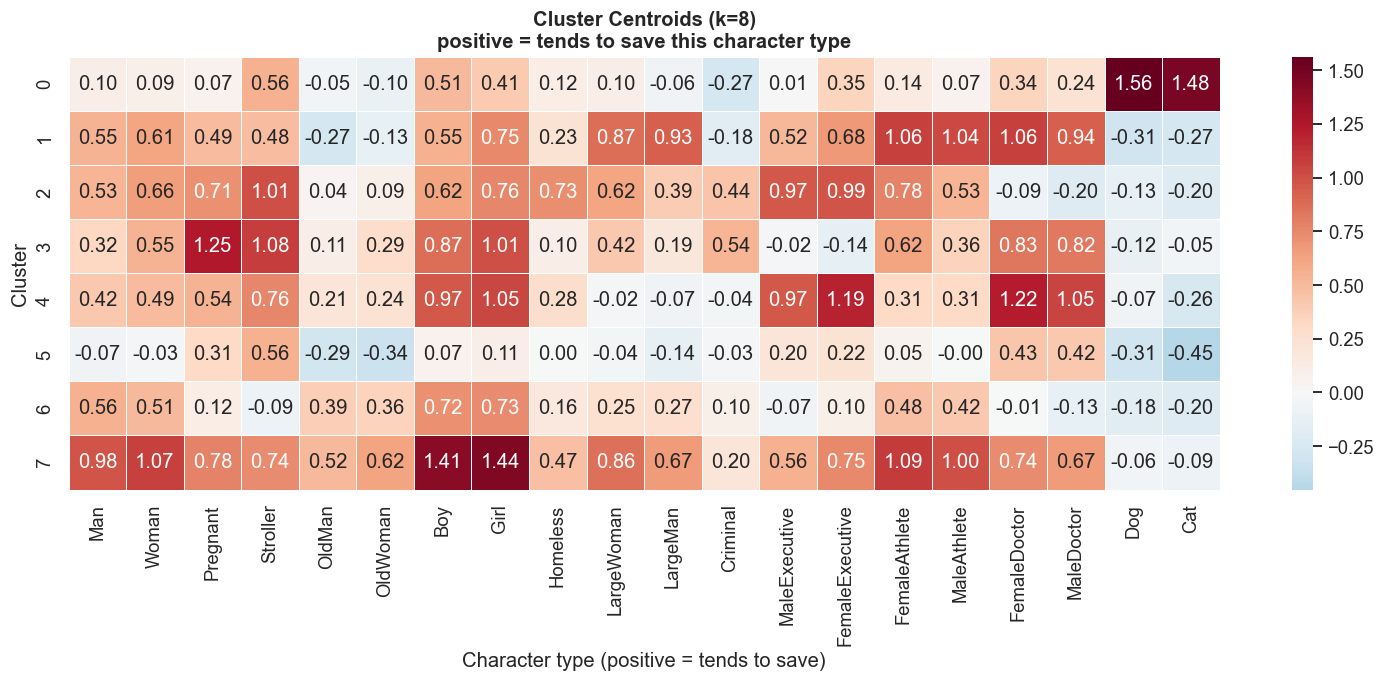

In [9]:
def cluster_users(profiles, k, char_cols=CHAR_COLS, seed=42):
    """
    K-means clustering on standardized preference profiles (no L2 normalization —
    magnitude matters, not just direction).
    Returns: labels (n_users,), centroid DataFrame (in original θ space)
    """
    scaler = StandardScaler()
    X = scaler.fit_transform(profiles)

    km = KMeans(n_clusters=k, n_init=20, random_state=seed)
    labels = km.fit_predict(X)

    # Centroids: average the *original* θ_n for each cluster
    centroid_df = pd.DataFrame(
        [profiles[labels == g].mean(axis=0) for g in range(k)],
        columns=char_cols,
    )
    centroid_df.index.name = "cluster"

    return labels, centroid_df


def plot_centroids(centroid_df, title="Cluster Centroids"):
    """Heatmap of cluster centroids (rows=clusters, cols=character types)."""
    fig, ax = plt.subplots(figsize=(14, max(3, len(centroid_df) * 0.8)))
    sns.heatmap(centroid_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                linewidths=0.5, ax=ax)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Cluster")
    ax.set_xlabel("Character type (positive = tends to save)")
    plt.tight_layout()
    plt.show()


# ── Run clustering with k=8 ──────────────────────────────────────────────
K = 8

# Diagnostic: check magnitude distribution
norms = np.linalg.norm(profiles, axis=1)
print(f"θ_n magnitude distribution: median={np.median(norms):.2f}, "
      f"mean={norms.mean():.2f}, max={norms.max():.2f}, min={norms.min():.2f}")
print(f"  p95={np.percentile(norms, 95):.2f}, p99={np.percentile(norms, 99):.2f}")

labels, centroid_df = cluster_users(profiles, k=K)

print(f"\nCluster sizes (k={K}):")
for g in range(K):
    n = (labels == g).sum()
    avg_norm = np.linalg.norm(profiles[labels == g], axis=1).mean()
    print(f"  Cluster {g}: {n:,} users ({n/len(labels)*100:.1f}%)  avg ||θ||={avg_norm:.2f}")

plot_centroids(centroid_df, title=f"Cluster Centroids (k={K})\npositive = tends to save this character type")

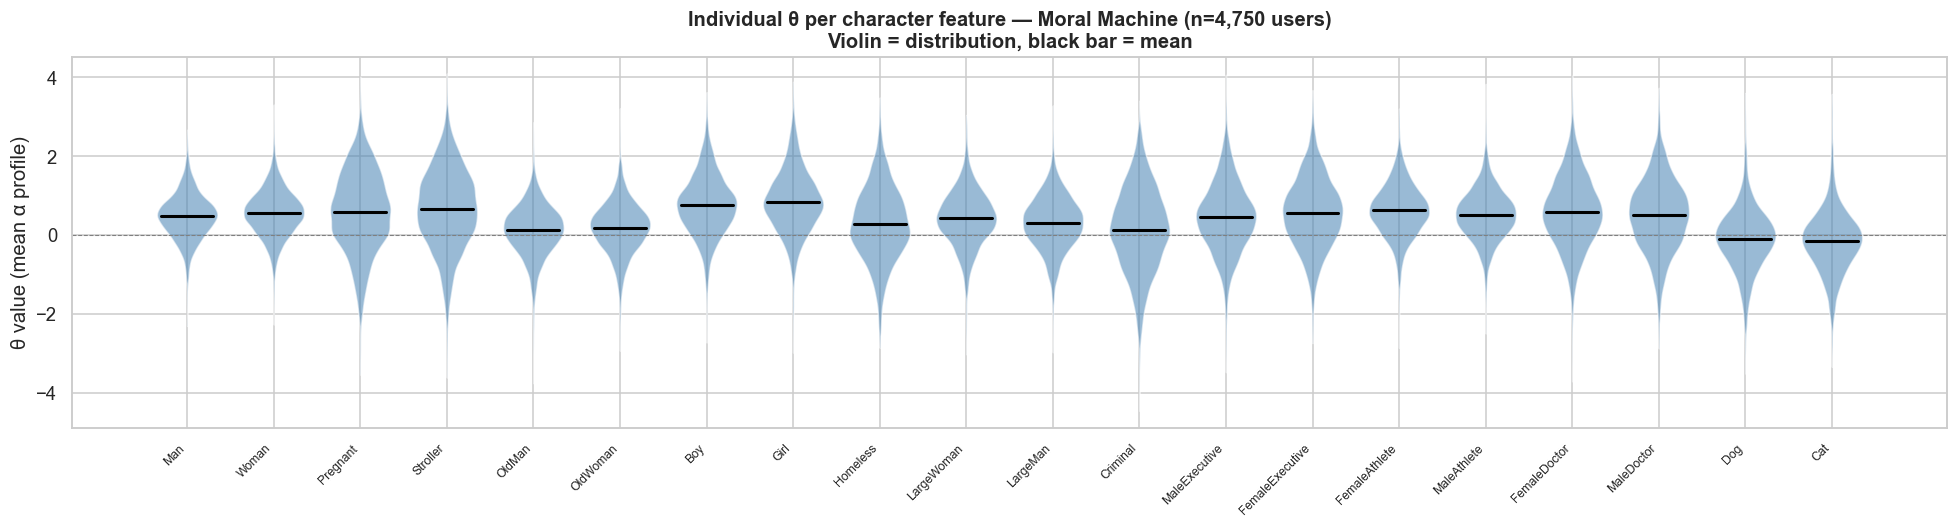

In [10]:
# ── Violin plot: individual θ per character feature (mean bar = pooled mean) ──
# 'profiles' = per-user mean-alpha preference vectors  (N_users, 20)
fig, ax = plt.subplots(figsize=(18, 5))

data_list  = [profiles[:, i] for i in range(len(CHAR_COLS))]
parts = ax.violinplot(data_list, positions=range(len(CHAR_COLS)),
                      showmedians=False, showextrema=False, widths=0.7)
for pc in parts['bodies']:
    pc.set_facecolor('steelblue')
    pc.set_alpha(0.55)

# Black bar = cross-user mean per feature
means = profiles.mean(axis=0)
for i, m in enumerate(means):
    ax.plot([i - 0.3, i + 0.3], [m, m], color='black', lw=2.0, zorder=4)

ax.axhline(0, color='grey', ls='--', lw=0.7)
ax.set_xticks(range(len(CHAR_COLS)))
ax.set_xticklabels(CHAR_COLS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('θ value (mean α profile)')
ax.set_title(
    f'Individual θ per character feature — Moral Machine (n={len(profiles):,} users)\n'
    'Violin = distribution, black bar = mean',
    fontweight='bold')
plt.tight_layout()
plt.show()


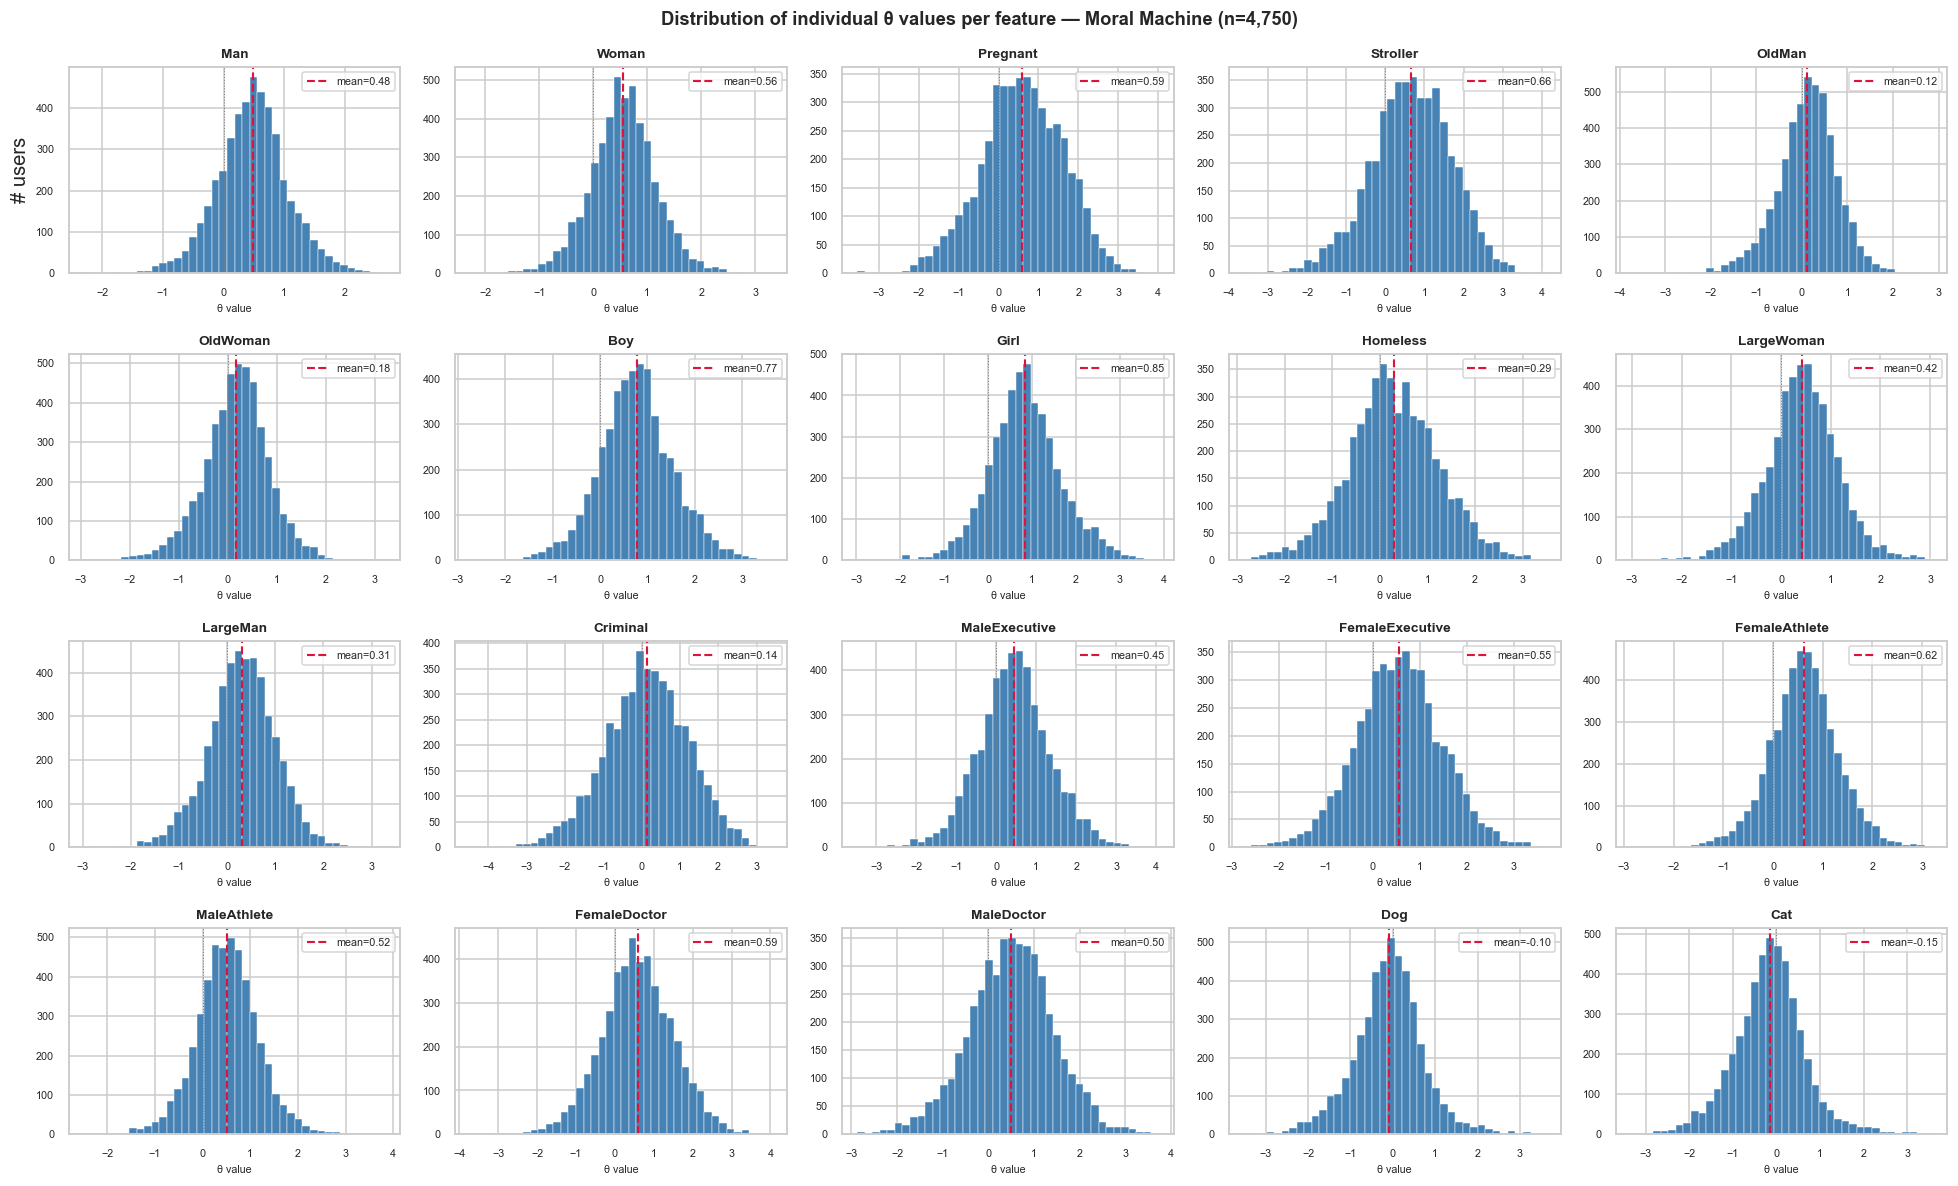

In [11]:
# ── Histogram of θ values per character feature ───────────────────────────
n_rows, n_cols = 4, 5   # 4×5 = 20 panels
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 11))
axes_flat = axes.flatten()

for ax, feat, i in zip(axes_flat, CHAR_COLS, range(len(CHAR_COLS))):
    vals = profiles[:, i]
    ax.hist(vals, bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(vals.mean(), color='crimson', lw=1.4, ls='--',
               label=f'mean={vals.mean():.2f}')
    ax.axvline(0, color='grey', lw=0.7, ls=':')
    ax.set_title(feat, fontweight='bold', fontsize=9)
    ax.set_xlabel('θ value', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

# hide any unused panels (none here, but good practice)
for ax in axes_flat[len(CHAR_COLS):]:
    ax.set_visible(False)

axes_flat[0].set_ylabel('# users')
plt.suptitle(
    f'Distribution of individual θ values per feature — Moral Machine (n={len(profiles):,})',
    fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


## 4. Fit BTL models and compute welfare/externalities

For each cluster, fit a per-group θ_g via logistic regression. Fit the pooled θ̂ (anonymous RLHF). Compute welfare and alignment externalities treating each cluster as a single agent.

In [12]:
def build_btl_data(alpha_df, user_ids, labels, char_cols=CHAR_COLS, max_obs=500_000):
    """
    Build BTL training arrays from α vectors, assigning each observation to its
    user's cluster.

    Returns: alpha (n, k_dim), y (n,), group_idx (n,), group_sizes dict
    """
    # Map UserID → cluster label
    user_to_cluster = dict(zip(user_ids, labels))
    alpha_df = alpha_df.copy()
    alpha_df["cluster"] = alpha_df["UserID"].map(user_to_cluster)
    alpha_df = alpha_df.dropna(subset=["cluster"])
    alpha_df["cluster"] = alpha_df["cluster"].astype(int)

    # Subsample if too large
    if len(alpha_df) > max_obs:
        alpha_df = alpha_df.sample(max_obs, random_state=42)
        print(f"  Subsampled to {max_obs:,} observations")

    alpha = alpha_df[char_cols].values.astype(float)
    y     = np.ones(len(alpha))   # label is always 1 (α = saved − notsaved)
    group = alpha_df["cluster"].values

    group_sizes = {g: (group == g).sum() for g in sorted(np.unique(group))}
    return alpha, y, group, group_sizes


def fit_btl(alpha, y, C=5.0):
    """Fit BTL model via logistic regression. Returns θ (k_dim,)."""
    # Flip half to get two classes (BTL-equivalent, needed by sklearn)
    X, y2 = _make_two_class(alpha)
    lr = LogisticRegression(fit_intercept=False, C=C, solver="lbfgs",
                            max_iter=2000, tol=1e-8)
    lr.fit(X, y2)
    return lr.coef_.ravel()


def fit_all_models(alpha, y, group, n_clusters, user_profiles=None):
    """
    Fit per-group θ_g and pooled θ̂.
    Returns: theta_groups list of (k,), theta_hat (k,), theta_bar (k,)
    """
    # Per-group BTL
    theta_groups = []
    for g in range(n_clusters):
        mask = group == g
        theta_g = fit_btl(alpha[mask], y[mask])
        theta_groups.append(theta_g)
        print(f"  θ_{g}: ||θ||={np.linalg.norm(theta_g):.3f}  ({mask.sum():,} obs)")

    # Pooled RLHF
    theta_hat = fit_btl(alpha, y)
    print(f"  θ̂ (pooled): ||θ||={np.linalg.norm(theta_hat):.3f}  ({len(y):,} obs)")

    # Group weights (proportion of observations)
    total = sum((group == g).sum() for g in range(n_clusters))
    weights = np.array([(group == g).sum() / total for g in range(n_clusters)])

    # Utilitarian mean: average of INDIVIDUAL user θ_n (not cluster-level θ_g)
    if user_profiles is not None:
        theta_bar = user_profiles.mean(axis=0)
        print(f"  θ̄ (utilitarian, from {len(user_profiles)} individual θ_n): ||θ||={np.linalg.norm(theta_bar):.3f}")
    else:
        theta_bar = sum(w * th for w, th in zip(weights, theta_groups))
        print(f"  θ̄ (utilitarian, from cluster θ_g): ||θ||={np.linalg.norm(theta_bar):.3f}")
    print(f"  ||θ̂ − θ̄|| = {np.linalg.norm(theta_hat - theta_bar):.4f}")

    return theta_groups, theta_hat, theta_bar, weights


# ── Build BTL data and fit models ─────────────────────────────────────────
print("Building BTL data...")
alpha_arr, y_arr, group_arr, group_sizes = build_btl_data(alpha_df, user_ids, labels)
print(f"  Group sizes: {group_sizes}")

print("\nFitting BTL models...")
theta_groups, theta_hat, theta_bar, group_weights = fit_all_models(
    alpha_arr, y_arr, group_arr, K, user_profiles=profiles
)

Building BTL data...
  Group sizes: {0: 12868, 1: 44609, 2: 60629, 3: 57873, 4: 58888, 5: 50862, 6: 55520, 7: 76043}

Fitting BTL models...
  θ_0: ||θ||=1.829  (12,868 obs)
  θ_1: ||θ||=2.673  (44,609 obs)
  θ_2: ||θ||=2.454  (60,629 obs)
  θ_3: ||θ||=2.488  (57,873 obs)
  θ_4: ||θ||=2.681  (58,888 obs)
  θ_5: ||θ||=0.791  (50,862 obs)
  θ_6: ||θ||=1.373  (55,520 obs)
  θ_7: ||θ||=3.802  (76,043 obs)
  θ̂ (pooled): ||θ||=1.952  (417,292 obs)
  θ̄ (utilitarian, from 4750 individual θ_n): ||θ||=2.200
  ||θ̂ − θ̄|| = 0.4362


In [13]:
# ── Four utilitarian/pooled theta vectors ─────────────────────────────────
#
#  1. theta_pop_util   : full-population utilitarian mean
#                        = mean of every individual user's α-profile (θ_n)
#                        (uses all top users, ignores cluster structure)
#
#  2. theta_clust_unw  : unweighted cluster utilitarian mean
#                        = simple average of the K cluster θ_g vectors
#                        (treats each cluster as equally important)
#
#  3. theta_clust_wt   : weighted cluster utilitarian mean
#                        = Σ_g  w_g · θ_g   where w_g = fraction of BTL
#                          training observations that came from cluster g
#
#  4. theta_pooled     : full pooled RLHF theta
#                        = single BTL model fit on ALL observations at once
#                          (anonymised — ignores group identity entirely)

theta_pop_util  = profiles.mean(axis=0)                          # (k,)
theta_clust_unw = np.mean(theta_groups, axis=0)                  # (k,)
theta_clust_wt  = sum(w * th for w, th in zip(group_weights, theta_groups))  # (k,)
theta_pooled    = theta_hat                                       # already fit

rows = [
    {"vector": "θ_pop_util  (full-pop utilitarian)",    **dict(zip(CHAR_COLS, theta_pop_util))},
    {"vector": "θ_clust_unw (unweighted cluster mean)", **dict(zip(CHAR_COLS, theta_clust_unw))},
    {"vector": "θ_clust_wt  (weighted cluster mean)",   **dict(zip(CHAR_COLS, theta_clust_wt))},
    {"vector": "θ_pooled    (full pooled RLHF)",        **dict(zip(CHAR_COLS, theta_pooled))},
]
for g, th in enumerate(theta_groups):
    rows.append({"vector": f"θ_{g}          (cluster {g})", **dict(zip(CHAR_COLS, th))})

theta_df = pd.DataFrame(rows).set_index("vector")

pd.set_option("display.float_format", "{:+.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
print(theta_df.to_string())
pd.reset_option("display.float_format")

theta_df

                                          Man   Woman  Pregnant  Stroller  OldMan  OldWoman     Boy    Girl  Homeless  LargeWoman  LargeMan  Criminal  MaleExecutive  FemaleExecutive  FemaleAthlete  MaleAthlete  FemaleDoctor  MaleDoctor     Dog     Cat
vector                                                                                                                                                                                                                                                     
θ_pop_util  (full-pop utilitarian)    +0.4781 +0.5586   +0.5889   +0.6557 +0.1187   +0.1776 +0.7697 +0.8494   +0.2883     +0.4211   +0.3092   +0.1378        +0.4453          +0.5527        +0.6223      +0.5172       +0.5894     +0.5008 -0.0959 -0.1491
θ_clust_unw (unweighted cluster mean) +0.4364 +0.4788   +0.5300   +0.6577 +0.2013   +0.2321 +0.6186 +0.6620   +0.2760     +0.4061   +0.3288   +0.0420        +0.4208          +0.5011        +0.5292      +0.4607       +0.5615     +0.5113 +0.2146 

,Man,Woman,Pregnant,Stroller,OldMan,OldWoman,Boy,Girl,Homeless,LargeWoman,LargeMan,Criminal,MaleExecutive,FemaleExecutive,FemaleAthlete,MaleAthlete,FemaleDoctor,MaleDoctor,Dog,Cat
vector,,,,,,,,,,,,,,,,,,,,
θ_pop_util (full-pop utilitarian),0.478113,0.558627,0.588858,0.655678,0.118660,0.177641,0.769674,0.849378,0.288312,0.421131,0.309162,0.137846,0.445275,0.552664,0.622287,0.517215,0.589427,0.500766,-0.095895,-0.149148
θ_clust_unw (unweighted cluster mean),0.436395,0.478792,0.529952,0.657712,0.201313,0.232081,0.618590,0.662010,0.276044,0.406109,0.328814,0.041981,0.420781,0.501133,0.529183,0.460707,0.561473,0.511262,0.214604,0.166458
θ_clust_wt (weighted cluster mean),0.494944,0.546481,0.595906,0.680778,0.248091,0.284449,0.685277,0.741171,0.314826,0.454513,0.373304,0.095204,0.467115,0.541117,0.589429,0.517309,0.582046,0.533825,0.135527,0.095981
θ_pooled (full pooled RLHF),0.441554,0.492034,0.536674,0.608743,0.205942,0.240157,0.622349,0.676687,0.280291,0.403039,0.320906,0.101361,0.416768,0.489007,0.534908,0.462497,0.514592,0.467490,0.108782,0.075776
θ_0 (cluster 0),0.153214,0.128225,0.121980,0.663039,0.059903,0.043795,0.383734,0.289344,0.096820,0.137919,0.040466,-0.309955,0.137679,0.292385,0.175976,0.118752,0.375225,0.311367,1.089763,0.955935
θ_1 (cluster 1),0.559425,0.609169,0.517517,0.521647,0.041667,0.120486,0.525354,0.657995,0.263819,0.750361,0.755666,-0.219054,0.511231,0.620862,0.871390,0.834418,0.991126,0.922420,0.067920,0.059700
θ_2 (cluster 2),0.512280,0.584700,0.663538,0.970093,0.165479,0.208250,0.573630,0.675793,0.618842,0.548573,0.407407,0.322539,0.858578,0.878490,0.651630,0.529955,0.044628,0.002636,0.097155,0.030895
θ_3 (cluster 3),0.405816,0.523131,1.127110,1.023996,0.220841,0.299999,0.725911,0.811070,0.163050,0.402980,0.265341,0.426683,0.091548,0.057855,0.554983,0.406574,0.766053,0.756286,0.083314,0.130103
θ_4 (cluster 4),0.416723,0.452286,0.551921,0.742632,0.258491,0.275528,0.773299,0.820540,0.321004,0.155748,0.113027,-0.045703,0.885593,1.030711,0.361787,0.347986,1.118353,1.011927,0.154620,0.012193


In [14]:
def make_uniform_qdep(char_cols=CHAR_COLS) -> np.ndarray:
    """
    All C(k,2) = 190 unordered pairwise matchups between character types,
    each appearing once.  α_z = e_i − e_j for i < j.
    """
    k = len(char_cols)
    rows = []
    for i in range(k):
        for j in range(i + 1, k):
            a = np.zeros(k)
            a[i] = 1.0
            a[j] = -1.0
            rows.append(a)
    return np.array(rows)   # (190, k)


def compute_welfare_and_externalities(alpha, group, theta_groups, theta_hat,
                                      theta_bar, weights, user_labels=None,
                                      n_deploy=10_000, seed=42,
                                      q_dep=None):
    """
    Compute per-group welfare and alignment externalities.

    Welfare (eq. 6):
        W_g(θ; z) = 2 (α^T θ_g) (σ(α^T θ) − ½)

    θ̄_clust = Σ_g w_g θ_g is used consistently for both W_opt and η.

    Alignment externality (eq. 16–17):
        Γ_{g,z} = (σ(α_z^T θ_g) − σ(α_z^T θ̂)) · (α_z^T η)

        η = J^{-1} · E_{z~q_dep}[(α_z^T θ̄_clust) v(α_z^T θ̂) α_z]  (eq. 17)
        J = E_{(n,z)~q_train}[v(α_z^T θ̂) α_z α_z^T]
        v(t) = σ(t)(1 − σ(t))

    Γ_{g,z} is per-query and returned in gamma_df (queries × groups).
    The welfare_df contains only welfare comparisons, not Gamma.

    Parameters
    ----------
    q_dep : None | "empirical" | "uniform" | np.ndarray (M, k)
        - None / "empirical" : random subsample of training queries
        - "uniform"          : all C(20,2)=190 unordered character-pair matchups
        - ndarray            : custom set of α vectors, used with equal weight
    """
    rng = np.random.default_rng(seed)
    k_dim = alpha.shape[1]
    n_clusters = len(theta_groups)

    # ── θ̄_clust = Σ_g w_g θ_g  (used for both W_opt and η) ─────────────
    theta_bar_clust = sum(w * th for w, th in zip(weights, theta_groups))
    print(f"  ||θ̄_clust|| = {np.linalg.norm(theta_bar_clust):.4f}  "
          f"||θ̂|| = {np.linalg.norm(theta_hat):.4f}")

    # ── Build deployment query set ────────────────────────────────────────
    if q_dep is None or q_dep == "empirical":
        idx = rng.choice(len(alpha), size=min(n_deploy, len(alpha)), replace=False)
        alpha_dep = alpha[idx]
        qdep_label = "empirical (subsample of training)"
    elif q_dep == "uniform":
        alpha_dep = make_uniform_qdep()
        qdep_label = "uniform over all 190 character-pair matchups"
    else:
        alpha_dep = np.asarray(q_dep)
        qdep_label = f"custom ({len(alpha_dep)} queries)"
    print(f"  q_dep: {qdep_label}  ({len(alpha_dep)} queries)")

    sigma_hat_dep = sigmoid(alpha_dep @ theta_hat)
    v_hat_dep     = sigma_hat_dep * (1 - sigma_hat_dep)
    sigma_opt_dep = sigmoid(alpha_dep @ theta_bar_clust)

    # ── Per-group welfare under each policy (eq. 6) ───────────────────────
    # W_opt uses θ̄_clust (weighted avg of group-level BTL thetas)
    results = []
    for g in range(n_clusters):
        logits_g = alpha_dep @ theta_groups[g]

        w_ideal = 0.5 * np.abs(logits_g).mean()
        w_opt   = (logits_g * (sigma_opt_dep - 0.5)).mean()
        w_rlhf  = (logits_g * (sigma_hat_dep - 0.5)).mean()

        results.append({
            "group": g, "weight": weights[g],
            "W_ideal": w_ideal, "W_opt": w_opt, "W_rlhf": w_rlhf,
            "rlhf_ratio":  w_rlhf / w_opt   if abs(w_opt)   > 1e-10 else np.nan,
            "total_ratio": w_rlhf / w_ideal  if abs(w_ideal) > 1e-10 else np.nan,
        })

    welfare_df = pd.DataFrame(results)

    # ── Fisher information J at θ̂ (over training data) ───────────────────
    sigma_hat_train = sigmoid(alpha @ theta_hat)
    v_hat_train     = sigma_hat_train * (1 - sigma_hat_train)
    J     = (alpha * v_hat_train[:, None]).T @ alpha / len(alpha)
    J_inv = np.linalg.inv(J + 1e-6 * np.eye(k_dim))

    # ── η = J^{-1} · E_{z~q_dep}[(α^T θ̄_clust) v(α^T θ̂) α]  (eq. 17) ───
    welfare_grad = ((alpha_dep * ((alpha_dep @ theta_bar_clust) * v_hat_dep)[:, None])
                    .mean(axis=0))
    eta = J_inv @ welfare_grad

    # ── Γ_{g,z} = (σ(α^T θ_g) − σ(α^T θ̂)) · (α^T η)  per query (eq. 16) ─
    alpha_dot_eta = alpha_dep @ eta
    gamma_mat = np.column_stack([
        (sigmoid(alpha_dep @ theta_groups[g]) - sigma_hat_dep) * alpha_dot_eta
        for g in range(n_clusters)
    ])  # (Q, G)
    gamma_df = pd.DataFrame(gamma_mat, columns=[f"g={g}" for g in range(n_clusters)])

    # ── Representation excess p̂_g − p*_g ─────────────────────────────────
    N = len(alpha)
    p_hat = np.array([(group == g).sum() / N for g in range(n_clusters)])
    if user_labels is not None:
        p_star = np.array([(user_labels == g).sum() / len(user_labels)
                           for g in range(n_clusters)])
    else:
        p_star = np.ones(n_clusters) / n_clusters
    print(f"  Representation: p̂={np.round(p_hat, 3)} vs p*={np.round(p_star, 3)}")
    print(f"  Excess (p̂ − p*): {np.round(p_hat - p_star, 4)}")

    return {
        "welfare_df":      welfare_df,
        "gamma_df":        gamma_df,
        "J_inv":           J_inv,
        "eta":             eta,
        "alpha_dep":       alpha_dep,
        "sigma_hat_dep":   sigma_hat_dep,
        "qdep_label":      qdep_label,
        "theta_bar_clust": theta_bar_clust,
    }


# ── Run with two deployment assumptions ───────────────────────────────────
results_by_qdep = {}
for qdep_name, qdep_val in [("empirical", "empirical"), ("uniform", "uniform")]:
    print(f"\n── q_dep = {qdep_name} ──")
    results_by_qdep[qdep_name] = compute_welfare_and_externalities(
        alpha_arr, group_arr, theta_groups, theta_hat, theta_bar, group_weights,
        user_labels=labels, q_dep=qdep_val,
    )

ext_results = results_by_qdep["empirical"]

print("\n── Welfare Table (empirical q_dep) ──")
print(ext_results["welfare_df"].round(4).to_string(index=False))


── q_dep = empirical ──
  ||θ̄_clust|| = 2.1806  ||θ̂|| = 1.9517
  q_dep: empirical (subsample of training)  (10000 queries)
  Representation: p̂=[0.031 0.107 0.145 0.139 0.141 0.122 0.133 0.182] vs p*=[0.037 0.116 0.138 0.128 0.141 0.132 0.13  0.177]
  Excess (p̂ − p*): [-0.0058 -0.0093  0.007   0.0103  0.0005 -0.0105  0.0032  0.0048]

── q_dep = uniform ──
  ||θ̄_clust|| = 2.1806  ||θ̂|| = 1.9517
  q_dep: uniform over all 190 character-pair matchups  (190 queries)
  Representation: p̂=[0.031 0.107 0.145 0.139 0.141 0.122 0.133 0.182] vs p*=[0.037 0.116 0.138 0.128 0.141 0.132 0.13  0.177]
  Excess (p̂ − p*): [-0.0058 -0.0093  0.007   0.0103  0.0005 -0.0105  0.0032  0.0048]

── Welfare Table (empirical q_dep) ──
 group  weight  W_ideal   W_opt  W_rlhf  rlhf_ratio  total_ratio
     0  0.0308   0.7591 -0.1125 -0.1081      0.9613      -0.1424
     1  0.1069   0.8969  0.4388  0.4129      0.9410       0.4604
     2  0.1453   0.7793  0.3865  0.3643      0.9425       0.4675
     3  0.1387  

In [15]:
# ── Per-query alignment externality on canonical test queries ─────────────
#
# Γ_{g,z} = (σ(α^T θ_g) − σ(α^T θ̂)) · (α^T η)
#   Factor 1: σ(α^T θ_g) − σ(α^T θ̂)  — group g's choice prob minus RLHF's
#   Factor 2: α^T η                     — social importance of this direction

def make_alpha(save: dict, kill: dict) -> np.ndarray:
    """Build α = chars(saved) − chars(killed). Pass {col_name: count}."""
    a = np.zeros(len(CHAR_COLS))
    for c, v in save.items():
        a[CHAR_COLS.index(c)] += v
    for c, v in kill.items():
        a[CHAR_COLS.index(c)] -= v
    return a

test_queries = {
    "Boy  vs  Girl":                   make_alpha({"Boy": 1},           {"Girl": 1}),
    "Pregnant  vs  OldWoman":          make_alpha({"Pregnant": 1},      {"OldWoman": 1}),
    "Dog  vs  Criminal":               make_alpha({"Dog": 1},           {"Criminal": 1}),
    "FemaleDoctor  vs  FemaleAthlete": make_alpha({"FemaleDoctor": 1},  {"FemaleAthlete": 1}),
    "Boy  vs  Man":                    make_alpha({"Boy": 1},           {"Man": 1}),
    "Homeless  vs  MaleExecutive":     make_alpha({"Homeless": 1},      {"MaleExecutive": 1}),
    "Stroller  vs  Criminal":          make_alpha({"Stroller": 1},      {"Criminal": 1}),
}

eta = ext_results["eta"]

rows = []
for qname, az in test_queries.items():
    alpha_dot_eta = az @ eta
    sigma_hat     = sigmoid(az @ theta_hat)
    for g in range(K):
        sigma_g  = sigmoid(az @ theta_groups[g])
        diff     = sigma_g - sigma_hat
        gamma_gz = diff * alpha_dot_eta
        rows.append({
            "query":                    qname,
            "group":                    f"g={g}",
            "σ(α·θ_g)−σ(α·θ̂)":       round(diff, 4),
            "σ(α·θ̂)":                 round(sigma_hat, 4),
            "α·η":                     round(alpha_dot_eta, 4),
            "Γ_{g,z}":                 round(gamma_gz, 4),
        })

df_tq = pd.DataFrame(rows)
pd.set_option("display.float_format", "{:+.4f}".format)
pd.set_option("display.max_columns", None)

# Γ table
print("Alignment externality Γ_{g,z} per test query and group\n")
print(df_tq.pivot(index="query", columns="group", values="Γ_{g,z}").to_string())

# Factor 1: difference in choice probability per group
print("\n── Factor 1: σ(α·θ_g) − σ(α·θ̂)  (group disagrees with RLHF model) ──")
print(df_tq.pivot(index="query", columns="group", values="σ(α·θ_g)−σ(α·θ̂)").to_string())

# Factor 2: social importance and RLHF baseline (query-level, same across groups)
print("\n── Factor 2: α·η  and  σ(α·θ̂)  (query-level quantities) ──")
decomp = (df_tq[df_tq["group"] == "g=0"]
          .set_index("query")[["σ(α·θ̂)", "α·η"]])
print(decomp.to_string())

pd.reset_option("display.float_format")


print("\nη (social welfare direction, query-independent):")
print(pd.Series(eta, index=CHAR_COLS).sort_values().round(4).to_string())

Alignment externality Γ_{g,z} per test query and group

group                               g=0     g=1     g=2     g=3     g=4     g=5     g=6     g=7
query                                                                                          
Boy  vs  Girl                   -0.0021 +0.0011 +0.0007 +0.0004 -0.0001 -0.0003 -0.0006 -0.0003
Boy  vs  Man                    +0.0024 -0.0106 -0.0059 +0.0067 +0.0085 -0.0050 -0.0015 +0.0055
Dog  vs  Criminal               -0.0162 -0.0038 +0.0031 +0.0047 -0.0026 +0.0011 +0.0009 -0.0025
FemaleDoctor  vs  FemaleAthlete +0.0014 +0.0009 -0.0035 +0.0014 +0.0046 +0.0014 -0.0017 -0.0019
Homeless  vs  MaleExecutive     -0.0032 +0.0036 +0.0034 -0.0069 +0.0137 +0.0008 -0.0078 -0.0021
Pregnant  vs  OldWoman          -0.0166 +0.0075 +0.0117 +0.0374 -0.0015 +0.0068 -0.0328 -0.0153
Stroller  vs  Criminal          +0.0534 +0.0278 +0.0170 +0.0110 +0.0333 -0.0023 -0.0730 +0.0288

── Factor 1: σ(α·θ_g) − σ(α·θ̂)  (group disagrees with RLHF model) ──
group    

In [16]:
# ── Query contentiousness ranking (over all 190 pairwise matchups) ────────
#
# max_abs_gamma = |σ(α^T θ_g) − σ(α^T θ̂)| × |α^T η|
#
# A query ranks high on max_abs_gamma either because groups genuinely
# disagree with the RLHF model (large disagreement factor) OR because the
# query sits in a socially important direction (large |α^T η|), or both.
# Showing all three separately makes the driver transparent.
#
# Metrics:
#  disagreement  : max_g |σ(α^T θ_g) − σ(α^T θ̂)|    — largest single-group deviation
#                  from the pooled RLHF model on this query
#  inter_group_std: std of σ(α^T θ_g) across groups   — pure group-vs-group
#  alpha_dot_eta  : |α^T η|                            — social importance
#  max_abs_gamma  : max_g |Γ_{g,z}|  = product of the two

uni     = results_by_qdep["uniform"]
A       = uni["alpha_dep"]           # (190, k)
eta     = uni["eta"]
sig_hat = uni["sigma_hat_dep"]       # σ(α^T θ̂)

query_labels = [
    f"{CHAR_COLS[i]} vs {CHAR_COLS[j]}"
    for i in range(len(CHAR_COLS))
    for j in range(i + 1, len(CHAR_COLS))
]

sig_groups    = np.column_stack([sigmoid(A @ theta_groups[g]) for g in range(K)])  # (190, K)
alpha_dot_eta = A @ eta                                                              # (190,)
gamma_mat_uni = (sig_groups - sig_hat[:, None]) * alpha_dot_eta[:, None]            # (190, K)

scores = pd.DataFrame({
    "query":          query_labels,
    "disagreement":   np.abs(sig_groups - sig_hat[:, None]).max(axis=1),
    "alpha_dot_eta":  np.abs(alpha_dot_eta),
    "max_abs_gamma":  np.abs(gamma_mat_uni).max(axis=1),
})

TOP = 10
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)

print("── Top queries by max |Γ_{g,z}| with decomposition ──")
print("(shows what drives each ranking: disagreement vs social importance)\n")
top_gamma = scores.nlargest(TOP, "max_abs_gamma")
print(top_gamma[["query", "disagreement", "alpha_dot_eta", "max_abs_gamma"]].to_string(index=False))

print(f"\n── Top {TOP} by max disagreement  max_g |σ(α^T θ_g) − σ(α^T θ̂)| ──")
print(scores.nlargest(TOP, "disagreement")[["query", "disagreement", "alpha_dot_eta", "max_abs_gamma"]].to_string(index=False))


print(f"\n── Top {TOP} by social importance |α^T η| (ignores group disagreement) ──")
print(scores.nlargest(TOP, "alpha_dot_eta")[["query", "alpha_dot_eta", "disagreement", "max_abs_gamma"]].to_string(index=False))

print(f"\n── Bottom {TOP} by max |Γ_{{g,z}}| (least consequential) ──")
print(scores.nsmallest(TOP, "max_abs_gamma")[["query", "disagreement", "alpha_dot_eta", "max_abs_gamma"]].to_string(index=False))

print(f"\n── Bottom {TOP} by max disagreement ──")
print(scores.nsmallest(TOP, "disagreement")[["query", "disagreement", "alpha_dot_eta", "max_abs_gamma"]].to_string(index=False))

print(f"\n── Bottom {TOP} by social importance |α^T η| ──")
print(scores.nsmallest(TOP, "alpha_dot_eta")[["query", "alpha_dot_eta", "disagreement", "max_abs_gamma"]].to_string(index=False))

pd.reset_option("display.float_format")

── Top queries by max |Γ_{g,z}| with decomposition ──
(shows what drives each ranking: disagreement vs social importance)

                      query  disagreement  alpha_dot_eta  max_abs_gamma
            Criminal vs Dog        0.3003         0.5877         0.1765
            Criminal vs Cat        0.2864         0.5655         0.1620
       Stroller vs Criminal        0.1388         1.0127         0.1406
   Criminal vs FemaleDoctor        0.1709         0.7669         0.1311
     Criminal vs MaleDoctor        0.1698         0.7625         0.1295
Criminal vs FemaleExecutive        0.1869         0.6490         0.1213
       LargeMan vs Criminal        0.1714         0.6011         0.1030
  Criminal vs MaleExecutive        0.1612         0.6320         0.1019
            Stroller vs Dog        0.2275         0.4250         0.0967
    Criminal vs MaleAthlete        0.1521         0.6249         0.0951

── Top 10 by max disagreement  max_g |σ(α^T θ_g) − σ(α^T θ̂)| ──
               quer

In [24]:
# ── Definition 27 Distortion ─────────────────────────────────────────
# (same generic function as in empirics_412foodrescue.ipynb)

def compute_distortion(theta_agents, lambdas, alpha_queries, weights=None):
    """
    Dist(µ_λ; θ) = W*(θ) / E[W(µ_λ(θ))]
    where µ_λ is the random dictatorship with weights λ.

    theta_agents  : (N, k)  reported preference vectors
    lambdas       : (N,)    mechanism weights (sum to 1)
    alpha_queries : (Q, k)  deployment query vectors
    weights       : (N,)    social welfare weights (default: uniform)
    """
    theta_agents  = np.array(theta_agents,  dtype=float)
    lambdas       = np.array(lambdas,       dtype=float)
    alpha_queries = np.array(alpha_queries, dtype=float)
    N, k = theta_agents.shape

    if weights is None:
        weights = np.ones(N) / N
    weights = np.array(weights, dtype=float)
    weights = weights / weights.sum()
    lambdas = lambdas / lambdas.sum()

    theta_bar  = weights @ theta_agents                                             # (k,)
    signs_n    = np.sign(alpha_queries @ theta_agents.T)                           # (Q, N)
    psi_n_star = (signs_n[:, :, None] * alpha_queries[:, None, :]).mean(axis=0)   # (N, k)
    psi_sp     = lambdas @ psi_n_star                                              # (k,)
    psi_star   = (np.sign(alpha_queries @ theta_bar)[:, None] * alpha_queries).mean(axis=0)
    W_star     = 0.5 * float(theta_bar @ psi_star)
    W_sp       = 0.5 * float(theta_bar @ psi_sp)
    distortion = W_star / W_sp if W_sp > 0 else np.inf

    return dict(distortion=distortion, W_star=W_star, W_sp=W_sp,
                psi_star=psi_star, psi_sp=psi_sp,
                psi_n_star=psi_n_star, theta_bar=theta_bar)


# ── Apply: k-means cluster thetas as agents ───────────────────────────
# Switch agents by replacing theta_agents / agent_labels / w_agents below.

# --- choose regime here -------------------------------------------
theta_agents = np.array(theta_groups)   # (K, 20)  k-means cluster thetas
agent_labels = [f'cluster_{g}' for g in range(len(theta_groups))]
w_agents     = np.array(group_weights)  # training-obs-fraction weights
# ------------------------------------------------------------------

N_agents = len(theta_agents)

# Lambda choices
lam_uniform = np.ones(N_agents) / N_agents
lam_welfare = w_agents.copy()

# Welfare-maximising lambda: point mass on argmax_m theta_bar^T psi_m*
res_tmp  = compute_distortion(theta_agents, lam_uniform, alpha_arr, w_agents)
n_star   = int(np.argmax(res_tmp['theta_bar'] @ res_tmp['psi_n_star'].T))
lam_opt  = np.zeros(N_agents); lam_opt[n_star] = 1.0

print('=== Distortion (Definition 27) — Moral Machine, k-means clusters ===')
print(f'N agents: {N_agents}  |  k features: {theta_agents.shape[1]}')
print()

for q_label, A_dep in [
    ('empirical q_dep', alpha_arr),
    ('uniform q_dep  ', make_uniform_qdep()),
]:
    print(f'── {q_label} ──')
    for lbl, lam in [
        ('Uniform λ (egalitarian)    ', lam_uniform),
        ('Welfare-weighted λ         ', lam_welfare),
        ('Welfare-maximising λ (dict)', lam_opt),
    ]:
        r = compute_distortion(theta_agents, lam, A_dep, w_agents)
        print(f'  {lbl}  W*={r["W_star"]:.4f}  E[W_sp]={r["W_sp"]:.4f}  '
              f'Dist={r["distortion"]:.4f}')
    print()

# Per-cluster welfare contribution under empirical q_dep
r0 = compute_distortion(theta_agents, lam_uniform, alpha_arr, w_agents)
agent_w = r0['theta_bar'] @ r0['psi_n_star'].T
print('theta_bar^T psi_n* per cluster (empirical q_dep):')
for lbl, val, wt in sorted(zip(agent_labels, agent_w, w_agents), key=lambda x: -x[1]):
    print(f'  {lbl}  (w={wt:.3f}): {val:.4f}')
print(f'\nWelfare-maximising dictator: {agent_labels[n_star]}  '
      f'W={agent_w[n_star]:.4f}  W*={r0["W_star"]:.4f}')


=== Distortion (Definition 27) — Moral Machine, k-means clusters ===
N agents: 8  |  k features: 20

── empirical q_dep ──
  Uniform λ (egalitarian)      W*=0.6988  E[W_sp]=0.6166  Dist=1.1332
  Welfare-weighted λ           W*=0.6988  E[W_sp]=0.6588  Dist=1.0606
  Welfare-maximising λ (dict)  W*=0.6988  E[W_sp]=0.6961  Dist=1.0039

── uniform q_dep   ──
  Uniform λ (egalitarian)      W*=0.2243  E[W_sp]=0.1474  Dist=1.5215
  Welfare-weighted λ           W*=0.2243  E[W_sp]=0.1577  Dist=1.4225
  Welfare-maximising λ (dict)  W*=0.2243  E[W_sp]=0.1882  Dist=1.1920

theta_bar^T psi_n* per cluster (empirical q_dep):
  cluster_7  (w=0.182): 0.6961
  cluster_3  (w=0.139): 0.6835
  cluster_4  (w=0.141): 0.6816
  cluster_2  (w=0.145): 0.6792
  cluster_6  (w=0.133): 0.6773
  cluster_1  (w=0.107): 0.6726
  cluster_5  (w=0.122): 0.5967
  cluster_0  (w=0.031): 0.2461

Welfare-maximising dictator: cluster_7  W=0.6961  W*=0.6988


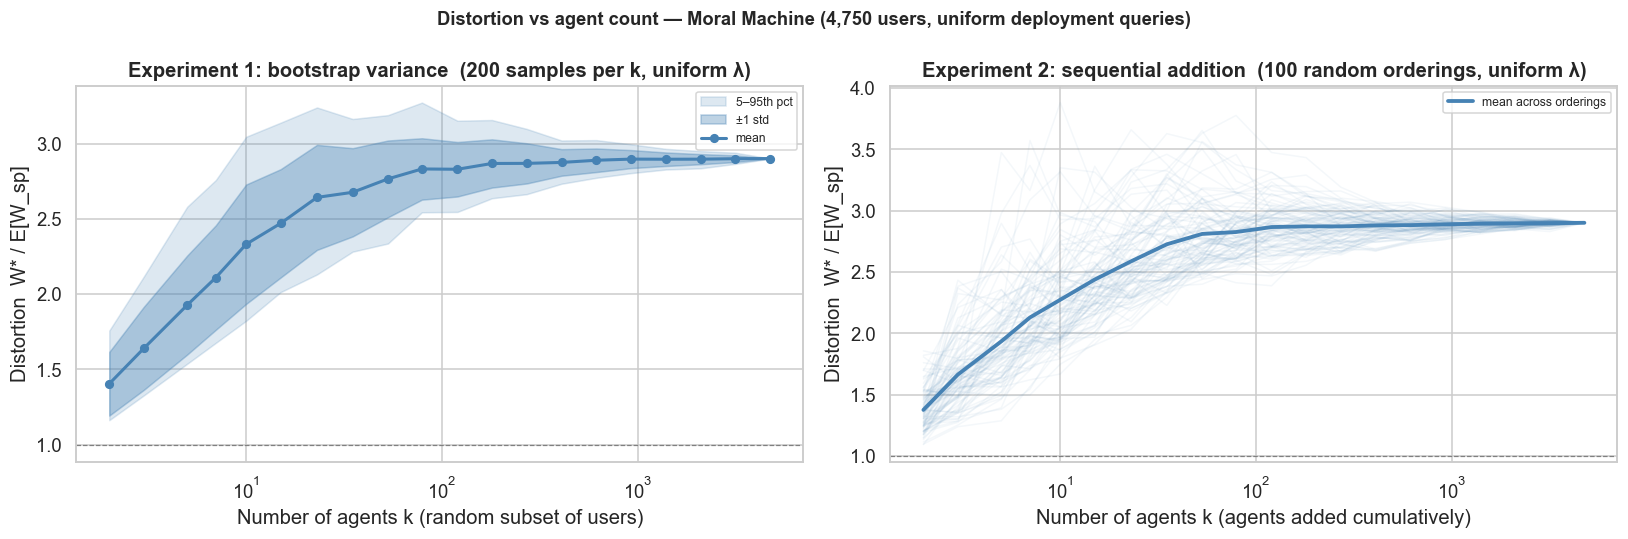

K values used: [2, 3, 5, 7, 10, 15, 23, 35, 53, 79, 120, 180, 271, 408, 614, 925, 1392, 2096, 3155, 4750]
Bootstrap: k=2      → 1.404 ± 0.211
Bootstrap: k= 4750 → 2.901 ± 0.0000


In [25]:
# ── Distortion bootstrap & sequential addition — Moral Machine ────────────
#
# Uses 20 log-spaced group sizes from 2 → N (covers both small and large
# subsets without evaluating every k up to ~5000).
#
# Experiment 1 (bootstrap variance):
#   For each k in K_vals, draw 200 random k-subsets → compute distortion.
#
# Experiment 2 (sequential addition):
#   Shuffle N agents into a random order; record distortion at the same
#   20 checkpoints. Repeat 100 random orderings.
#
# Deployment queries: make_uniform_qdep() — all 190 pairwise character
# matchups (complete, canonical query set for this domain).

theta_arr_m = profiles.astype(float)              # (N_users, 20)
N_ag_m      = len(theta_arr_m)
w_arr_m     = np.ones(N_ag_m) / N_ag_m            # uniform welfare weights
A_dep_m     = make_uniform_qdep().astype(float)   # (190, 20)

# 20 log-spaced k values from 2 → N
K_vals_m  = np.unique(
    np.round(np.logspace(np.log10(2), np.log10(N_ag_m), 20)).astype(int)
).tolist()
N_BOOT_M  = 200
N_ORDER_M = 100

rng_m = np.random.default_rng(1)

# ── Experiment 1: bootstrap variance ─────────────────────────────────────
boot_means_m, boot_stds_m, boot_p5_m, boot_p95_m = [], [], [], []

for k in K_vals_m:
    dists = []
    for _ in range(N_BOOT_M):
        idx   = rng_m.choice(N_ag_m, size=k, replace=False)
        th_k  = theta_arr_m[idx]
        w_k   = w_arr_m[idx];  w_k = w_k / w_k.sum()
        lam_k = np.ones(k) / k
        r     = compute_distortion(th_k, lam_k, A_dep_m, w_k)
        dists.append(r['distortion'])
    dists = np.array(dists)
    boot_means_m.append(dists.mean())
    boot_stds_m.append(dists.std())
    boot_p5_m.append(np.percentile(dists, 5))
    boot_p95_m.append(np.percentile(dists, 95))

boot_means_m = np.array(boot_means_m)
boot_stds_m  = np.array(boot_stds_m)
boot_p5_m    = np.array(boot_p5_m)
boot_p95_m   = np.array(boot_p95_m)

# ── Experiment 2: sequential addition ────────────────────────────────────
K_set_m   = set(K_vals_m)
seq_all_m = []

for _ in range(N_ORDER_M):
    order = rng_m.permutation(N_ag_m)
    path  = []
    for k in K_vals_m:
        idx   = order[:k]
        th_k  = theta_arr_m[idx]
        w_k   = w_arr_m[idx];  w_k = w_k / w_k.sum()
        lam_k = np.ones(k) / k
        r     = compute_distortion(th_k, lam_k, A_dep_m, w_k)
        path.append(r['distortion'])
    seq_all_m.append(path)

seq_all_m  = np.array(seq_all_m)
seq_mean_m = seq_all_m.mean(axis=0)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.fill_between(K_vals_m, boot_p5_m, boot_p95_m,
                alpha=0.18, color='steelblue', label='5–95th pct')
ax.fill_between(K_vals_m, boot_means_m - boot_stds_m, boot_means_m + boot_stds_m,
                alpha=0.35, color='steelblue', label='±1 std')
ax.plot(K_vals_m, boot_means_m, 'o-', color='steelblue', lw=2, ms=5, label='mean')
ax.axhline(1.0, color='grey', ls='--', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel('Number of agents k (random subset of users)')
ax.set_ylabel('Distortion  W* / E[W_sp]')
ax.set_title(f'Experiment 1: bootstrap variance  ({N_BOOT_M} samples per k, uniform λ)',
             fontweight='bold')
ax.legend(fontsize=8)

ax = axes[1]
for path in seq_all_m:
    ax.plot(K_vals_m, path, color='steelblue', alpha=0.06, lw=1)
ax.plot(K_vals_m, seq_mean_m, color='steelblue', lw=2.5, label='mean across orderings')
ax.axhline(1.0, color='grey', ls='--', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel('Number of agents k (agents added cumulatively)')
ax.set_ylabel('Distortion  W* / E[W_sp]')
ax.set_title(f'Experiment 2: sequential addition  ({N_ORDER_M} random orderings, uniform λ)',
             fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle(f'Distortion vs agent count — Moral Machine ({N_ag_m:,} users, uniform deployment queries)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print(f"K values used: {K_vals_m}")
print(f"Bootstrap: k=2      → {boot_means_m[0]:.3f} ± {boot_stds_m[0]:.3f}")
print(f"Bootstrap: k={K_vals_m[-1]:5d} → {boot_means_m[-1]:.3f} ± {boot_stds_m[-1]:.4f}")


In [18]:
# # ── Visualize Ψ for Moral Machine data ──────────────────────────────
# from sklearn.decomposition import PCA

# def psi_mm_batch(thetas, A):
#     """thetas (M, k), A (Q, k) -> psi values (M, k)"""
#     w = (sigmoid(thetas @ A.T) - 0.5)          # (M, Q)
#     return (w[:, :, None] * A[None]).mean(axis=1)   # (M, k)

# def psi_mm(theta, A):
#     w = (sigmoid(A @ theta) - 0.5)
#     return (A * w[:, None]).mean(axis=0)

# # Sweep θ over many directions + radii in R^20
# rng_vis  = np.random.default_rng(0)
# n_dirs   = 2000
# raw_dirs = rng_vis.standard_normal((n_dirs, len(CHAR_COLS)))
# unit_dirs = raw_dirs / np.linalg.norm(raw_dirs, axis=1, keepdims=True)
# radii    = np.concatenate([np.linspace(0, 0.5, 10),
#                             np.linspace(0.5, 5, 30),
#                             np.geomspace(5, 200, 20)])
# all_theta = np.vstack([r * unit_dirs for r in radii])
# norms_all = np.linalg.norm(all_theta, axis=1)

# # Named theta vectors to annotate
# named = {'theta_hat (RLHF)': theta_hat}
# for g, th in enumerate(theta_groups):
#     named[f'cluster_{g}'] = th
# named['theta_bar (wt)'] = theta_clust_wt
# markers = ['*', 'D', 's', '^', 'o', 'P', 'X', 'v', '<', '>', 'h', 'H']

# fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# for ax, (q_label, A_dep) in zip(axes, [
#     ('Empirical q_dep', alpha_arr),
#     ('Uniform q_dep (190 matchups)', make_uniform_qdep()),
# ]):
#     all_psi = psi_mm_batch(all_theta, A_dep)       # (M, 20)
#     pca = PCA(n_components=2).fit(all_psi)
#     psi_2d = pca.transform(all_psi)                # (M, 2)

#     pts = psi_2d
#     hb  = ax.hexbin(pts[:, 0], pts[:, 1], gridsize=60, cmap='YlOrRd',
#                     mincnt=1, linewidths=0)
#     plt.colorbar(hb, ax=ax, label='# theta values')

#     for (lbl, th), mk in zip(named.items(), markers):
#         p = pca.transform(psi_mm(th, A_dep).reshape(1, -1))
#         ax.scatter(p[0, 0], p[0, 1], s=150, marker=mk, zorder=10,
#                    label=lbl, edgecolors='black', linewidths=0.6)

#     ax.scatter([0], [0], c='black', s=60, marker='x', zorder=9)
#     ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
#     ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
#     ax.set_title(q_label, fontweight='bold')
#     ax.legend(fontsize=7, loc='upper left', ncol=2)

#     print(f'\n── {q_label} PCA loadings (top features per axis) ──')
#     loadings = pd.DataFrame(pca.components_.T, index=CHAR_COLS,
#                             columns=['PC1', 'PC2'])
#     for ax_name in ['PC1', 'PC2']:
#         top = loadings[ax_name].abs().nlargest(5).index.tolist()
#         print(f'  {ax_name}: ' + ', '.join(
#             f'{c}({loadings.loc[c,ax_name]:+.2f})' for c in top))
#     print(f'  Variance explained: '
#           f'PC1={pca.explained_variance_ratio_[0]:.1%}  '
#           f'PC2={pca.explained_variance_ratio_[1]:.1%}  '
#           f'total={pca.explained_variance_ratio_.sum():.1%}')

# plt.suptitle('Impact set Ψ — Moral Machine (k=20, PCA projection)',
#              fontweight='bold', fontsize=13)
# plt.tight_layout()
# plt.show()


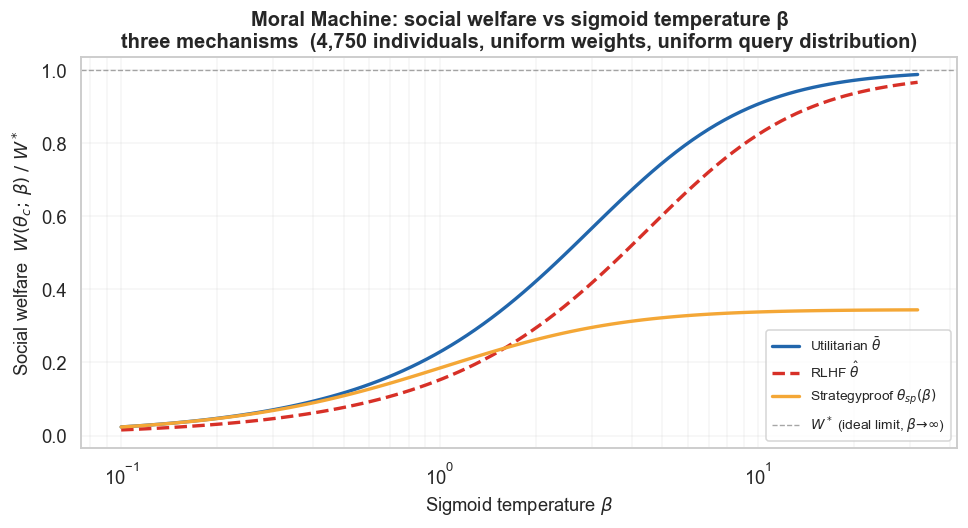

W* (utilitarian boundary optimal): 0.3048


In [19]:
# ── Social welfare vs sigmoid temperature β — Moral Machine ──────────────
#
# W(θ_c; β) = Σ_n w_n · E_z[ 2(α·θ_n)(σ(β·α·θ_c) − 0.5) ]
# Normalized by W* = E_z[|α·θ̄|].
# Three mechanisms: utilitarian θ̄, RLHF θ̂, strategyproof θ_sp(β).
#
# Deployment query distribution: make_uniform_qdep() — all 190 pairwise
# character matchups (the natural complete query set for this domain).

from scipy.special import expit
from scipy.optimize import minimize

theta_arr   = profiles.astype(float)                    # (N_users, 20)
N_agents    = len(theta_arr)
w_uniform   = np.ones(N_agents) / N_agents
theta_bar_m = theta_bar.astype(float)                   # population utilitarian mean
theta_rlhf_m = theta_hat.astype(float)                  # pooled RLHF estimate
alpha_q     = make_uniform_qdep().astype(float)         # (190, 20) deployment queries

def phi_all(theta_agents, beta, alpha):
    logits = alpha @ theta_agents.T
    factor = (expit(beta * logits) - 0.5)
    return factor.T @ alpha / len(alpha)                # (N, k)

def phi_inv(target, beta, alpha, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])
    def loss_and_grad(theta):
        s        = expit(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * np.dot(residual, residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    return res.x

def social_welfare_beta(theta_deploy, beta, theta_agents, weights, alpha):
    factor = (expit(beta * (alpha @ theta_deploy)) - 0.5)
    return float(weights @ (alpha @ theta_agents.T * factor[:, None]).mean(axis=0))

psi_star_m = (np.sign(alpha_q @ theta_bar_m)[:, None] * alpha_q).mean(axis=0)
W_star_m   = float(theta_bar_m @ psi_star_m)

betas = np.logspace(-1, 1.5, 100)

W_util_sw, W_rlhf_sw, W_sp_sw = [], [], []
theta_sp_prev = theta_bar_m.copy()

for b in betas:
    phi_avg        = phi_all(theta_arr, b, alpha_q).mean(axis=0)
    theta_sp       = phi_inv(phi_avg, b, alpha_q, theta_init=theta_sp_prev)
    theta_sp_prev  = theta_sp.copy()
    W_util_sw.append(social_welfare_beta(theta_bar_m,  b, theta_arr, w_uniform, alpha_q))
    W_rlhf_sw.append(social_welfare_beta(theta_rlhf_m, b, theta_arr, w_uniform, alpha_q))
    W_sp_sw.append(  social_welfare_beta(theta_sp,     b, theta_arr, w_uniform, alpha_q))

W_util_sw = np.array(W_util_sw) / W_star_m
W_rlhf_sw = np.array(W_rlhf_sw) / W_star_m
W_sp_sw   = np.array(W_sp_sw)   / W_star_m

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(betas, W_util_sw, color='#2166ac', ls='-',  lw=2.2, label=r'Utilitarian $\bar\theta$')
ax.plot(betas, W_rlhf_sw, color='#d73027', ls='--', lw=2.2, label=r'RLHF $\hat\theta$')
ax.plot(betas, W_sp_sw,   color='#f4a736', ls='-',  lw=2.2, label=r'Strategyproof $\theta_{sp}(\beta)$')
ax.axhline(1.0, color='grey', ls='--', lw=0.9, alpha=0.7,
           label=r'$W^*$ (ideal limit, $\beta\to\infty$)')
ax.set_xscale('log')
ax.set_xlabel(r'Sigmoid temperature $\beta$', fontsize=12)
ax.set_ylabel(r'Social welfare  $W(\theta_c;\,\beta)\;/\;W^*$', fontsize=12)
ax.set_title(f'Moral Machine: social welfare vs sigmoid temperature β\n'
             f'three mechanisms  ({N_agents:,} individuals, uniform weights, '
             f'uniform query distribution)',
             fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.show()
print(f"W* (utilitarian boundary optimal): {W_star_m:.4f}")


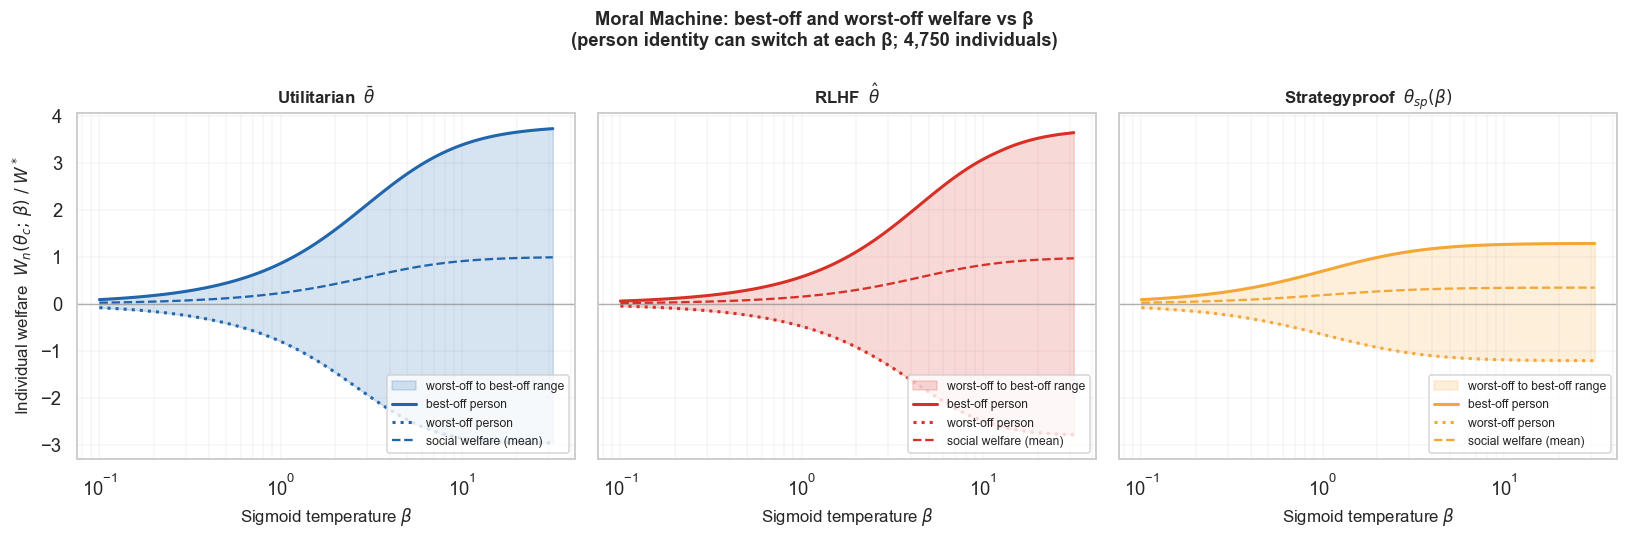

Utilitarian     min welfare at β=32: -2.9578  max: +3.7230
RLHF            min welfare at β=32: -2.7816  max: +3.6383
Strategyproof   min welfare at β=32: -1.2092  max: +1.2823


In [20]:
# ── Individual welfare bounds vs β — Moral Machine ───────────────────────
#
# For each mechanism and each β, compute W_n(θ_c(β); β) for all N users,
# take the pointwise max and min. Person can switch at each β.
# Three subplots: utilitarian, RLHF, strategyproof.

from scipy.special import expit
from scipy.optimize import minimize

theta_arr    = profiles.astype(float)
N_agents     = len(theta_arr)
w_uniform    = np.ones(N_agents) / N_agents
theta_bar_m  = theta_bar.astype(float)
theta_rlhf_m = theta_hat.astype(float)
alpha_q      = make_uniform_qdep().astype(float)

def phi_all(theta_agents, beta, alpha):
    logits = alpha @ theta_agents.T
    factor = (expit(beta * logits) - 0.5)
    return factor.T @ alpha / len(alpha)

def phi_inv(target, beta, alpha, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])
    def loss_and_grad(theta):
        s        = expit(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * np.dot(residual, residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    return res.x

def per_agent_welfare(theta_deploy, beta, theta_agents, alpha):
    factor = (expit(beta * (alpha @ theta_deploy)) - 0.5)
    return (alpha @ theta_agents.T * factor[:, None]).mean(axis=0)

psi_star_m = (np.sign(alpha_q @ theta_bar_m)[:, None] * alpha_q).mean(axis=0)
W_star_m   = float(theta_bar_m @ psi_star_m)

betas = np.logspace(-1, 1.5, 100)

records = {lbl: {'max': [], 'min': [], 'mean': []}
           for lbl in ['Utilitarian', 'RLHF', 'Strategyproof']}

theta_sp_prev = theta_bar_m.copy()

for b in betas:
    phi_avg       = phi_all(theta_arr, b, alpha_q).mean(axis=0)
    theta_sp      = phi_inv(phi_avg, b, alpha_q, theta_init=theta_sp_prev)
    theta_sp_prev = theta_sp.copy()

    for lbl, th_c in [('Utilitarian',   theta_bar_m),
                      ('RLHF',          theta_rlhf_m),
                      ('Strategyproof', theta_sp)]:
        W_n = per_agent_welfare(th_c, b, theta_arr, alpha_q) / W_star_m
        records[lbl]['max'].append(W_n.max())
        records[lbl]['min'].append(W_n.min())
        records[lbl]['mean'].append(W_n.mean())

for lbl in records:
    for k in records[lbl]:
        records[lbl][k] = np.array(records[lbl][k])

mech_colors = {'Utilitarian': '#2166ac', 'RLHF': '#d73027', 'Strategyproof': '#f4a736'}
mech_titles = {
    'Utilitarian':   r'Utilitarian  $\bar\theta$',
    'RLHF':          r'RLHF  $\hat\theta$',
    'Strategyproof': r'Strategyproof  $\theta_{sp}(\beta)$',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, lbl in zip(axes, ['Utilitarian', 'RLHF', 'Strategyproof']):
    c   = mech_colors[lbl]
    rec = records[lbl]
    ax.fill_between(betas, rec['min'], rec['max'],
                    color=c, alpha=0.18, label='worst-off to best-off range')
    ax.plot(betas, rec['max'],  color=c, lw=2.0, ls='-',  label='best-off person')
    ax.plot(betas, rec['min'],  color=c, lw=2.0, ls=':',  label='worst-off person')
    ax.plot(betas, rec['mean'], color=c, lw=1.5, ls='--', label='social welfare (mean)')
    ax.axhline(0, color='grey', lw=0.9, ls='-', alpha=0.6)
    ax.set_xscale('log')
    ax.set_xlabel(r'Sigmoid temperature $\beta$', fontsize=11)
    ax.set_title(mech_titles[lbl], fontweight='bold', fontsize=11)
    ax.grid(True, which='both', alpha=0.18)
    ax.legend(fontsize=8, loc='lower right')

axes[0].set_ylabel(r'Individual welfare  $W_n(\theta_c;\,\beta)\;/\;W^*$', fontsize=11)
fig.suptitle(f'Moral Machine: best-off and worst-off welfare vs β\n'
             f'(person identity can switch at each β; {N_agents:,} individuals)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

for lbl in ['Utilitarian', 'RLHF', 'Strategyproof']:
    print(f"{lbl:14s}  min welfare at β=32: {records[lbl]['min'][-1]:+.4f}  "
          f"max: {records[lbl]['max'][-1]:+.4f}")


In [ ]:
# ── Agent identity diagnostic: which agent is best/worst-off at each β ───
# (Moral Machine, ~5000 users)
from scipy.special import expit
from scipy.optimize import minimize
from collections import Counter

theta_arr    = profiles.astype(float)
N_agents     = len(theta_arr)
w_uniform    = np.ones(N_agents) / N_agents
theta_bar_m  = theta_bar.astype(float)
theta_rlhf_m = theta_hat.astype(float)
alpha_q      = make_uniform_qdep().astype(float)

def _phi_all(theta_agents, beta, alpha):
    logits = alpha @ theta_agents.T
    factor = (expit(beta * logits) - 0.5)
    return factor.T @ alpha / len(alpha)

def _phi_inv(target, beta, alpha, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])
    def loss_and_grad(theta):
        s        = expit(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * np.dot(residual, residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    return res.x

def _per_agent_welfare(theta_deploy, beta, theta_agents, alpha):
    factor = (expit(beta * (alpha @ theta_deploy)) - 0.5)
    return (alpha @ theta_agents.T * factor[:, None]).mean(axis=0)

psi_star_m = (np.sign(alpha_q @ theta_bar_m)[:, None] * alpha_q).mean(axis=0)
W_star_m   = float(theta_bar_m @ psi_star_m)

betas = np.logspace(-1, 1.5, 100)

argrecords = {lbl: {'argmin': [], 'argmax': []}
              for lbl in ['Utilitarian', 'RLHF', 'Strategyproof']}

theta_sp_prev = theta_bar_m.copy()
for b in betas:
    phi_avg       = _phi_all(theta_arr, b, alpha_q).mean(axis=0)
    theta_sp      = _phi_inv(phi_avg, b, alpha_q, theta_init=theta_sp_prev)
    theta_sp_prev = theta_sp.copy()
    for lbl, th_c in [('Utilitarian',   theta_bar_m),
                      ('RLHF',          theta_rlhf_m),
                      ('Strategyproof', theta_sp)]:
        W_n = _per_agent_welfare(th_c, b, theta_arr, alpha_q) / W_star_m
        argrecords[lbl]['argmin'].append(int(W_n.argmin()))
        argrecords[lbl]['argmax'].append(int(W_n.argmax()))

# ── Plot ──────────────────────────────────────────────────────────────────
mech_colors = {'Utilitarian': '#2166ac', 'RLHF': '#d73027', 'Strategyproof': '#f4a736'}
mech_titles = {
    'Utilitarian':   r'Utilitarian  $\bar\theta$',
    'RLHF':          r'RLHF  $\hat\theta$',
    'Strategyproof': r'Strategyproof  $\theta_{sp}(\beta)$',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, lbl in zip(axes, ['Utilitarian', 'RLHF', 'Strategyproof']):
    c        = mech_colors[lbl]
    amin_idx = argrecords[lbl]['argmin']
    amax_idx = argrecords[lbl]['argmax']

    ax.step(betas, amin_idx, where='mid', color=c, lw=2.0, ls=':', label='worst-off agent')
    ax.step(betas, amax_idx, where='mid', color=c, lw=2.0, ls='-', label='best-off agent')
    ax.scatter(betas, amin_idx, color=c, s=14, alpha=0.6, marker='v', zorder=3)
    ax.scatter(betas, amax_idx, color=c, s=14, alpha=0.6, marker='^', zorder=3)

    ax.set_xscale('log')
    ax.set_xlabel(r'$\beta$', fontsize=11)
    ax.set_ylim(-50, N_agents + 50)
    ax.set_title(mech_titles[lbl], fontweight='bold', fontsize=11)
    ax.grid(True, which='both', alpha=0.15)
    ax.legend(fontsize=8, loc='best')

axes[0].set_ylabel(f'Agent index (0-{N_agents-1})', fontsize=11)

fig.suptitle(f'Moral Machine: which agent is best-off / worst-off at each β\n'
             f'(▲/solid = best-off, ▼/dotted = worst-off; {N_agents:,} users)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("Worst-off agent (argmin) summary (agent index):")
for lbl in ['Utilitarian', 'RLHF', 'Strategyproof']:
    idxs = argrecords[lbl]['argmin']
    cnt  = Counter(idxs)
    top5 = sorted(cnt.items(), key=lambda x: -x[1])[:5]
    n_switches = sum(1 for i in range(1, len(idxs)) if idxs[i] != idxs[i-1])
    print(f"  {lbl:14s}: top-5 {top5}  n_switches={n_switches}  n_distinct={len(cnt)}")

print("\nBest-off agent (argmax) summary (agent index):")
for lbl in ['Utilitarian', 'RLHF', 'Strategyproof']:
    idxs = argrecords[lbl]['argmax']
    cnt  = Counter(idxs)
    top5 = sorted(cnt.items(), key=lambda x: -x[1])[:5]
    n_switches = sum(1 for i in range(1, len(idxs)) if idxs[i] != idxs[i-1])
    print(f"  {lbl:14s}: top-5 {top5}  n_switches={n_switches}  n_distinct={len(cnt)}")


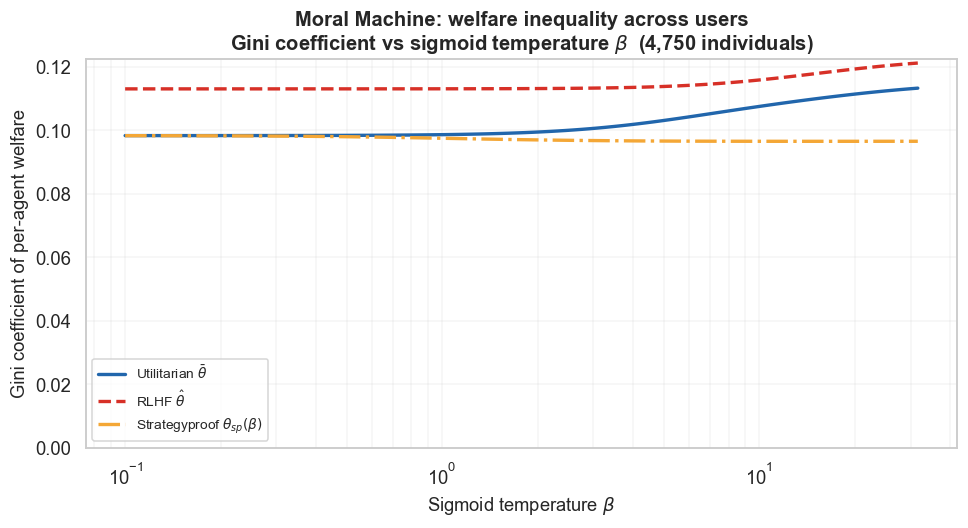

Utilitarian     β=0.1: 0.098   β=1: 0.099   β=32: 0.113
RLHF            β=0.1: 0.113   β=1: 0.113   β=32: 0.121
SP              β=0.1: 0.098   β=1: 0.098   β=32: 0.097


In [21]:
# ── Gini coefficient vs β — Moral Machine ────────────────────────────────

from scipy.special import expit
from scipy.optimize import minimize

theta_arr    = profiles.astype(float)
N_agents     = len(theta_arr)
w_uniform    = np.ones(N_agents) / N_agents
theta_bar_m  = theta_bar.astype(float)
theta_rlhf_m = theta_hat.astype(float)
alpha_q      = make_uniform_qdep().astype(float)

def phi_all(theta_agents, beta, alpha):
    logits = alpha @ theta_agents.T
    factor = (expit(beta * logits) - 0.5)
    return factor.T @ alpha / len(alpha)

def phi_inv(target, beta, alpha, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])
    def loss_and_grad(theta):
        s        = expit(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * np.dot(residual, residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    return res.x

def per_agent_welfare(theta_deploy, beta, theta_agents, alpha):
    factor = (expit(beta * (alpha @ theta_deploy)) - 0.5)
    return (alpha @ theta_agents.T * factor[:, None]).mean(axis=0)

def gini(values):
    v = np.array(values, dtype=float)
    v = v - v.min()
    if v.sum() < 1e-12:
        return 0.0
    v = np.sort(v)
    N = len(v)
    return float((2 * (np.arange(1, N + 1) * v).sum()) / (N * v.sum()) - (N + 1) / N)

betas = np.logspace(-1, 1.5, 100)

gini_util, gini_rlhf, gini_sp = [], [], []
theta_sp_prev = theta_bar_m.copy()

for b in betas:
    phi_avg       = phi_all(theta_arr, b, alpha_q).mean(axis=0)
    theta_sp      = phi_inv(phi_avg, b, alpha_q, theta_init=theta_sp_prev)
    theta_sp_prev = theta_sp.copy()

    W_util = per_agent_welfare(theta_bar_m,  b, theta_arr, alpha_q)
    W_rlhf = per_agent_welfare(theta_rlhf_m, b, theta_arr, alpha_q)
    W_sp   = per_agent_welfare(theta_sp,     b, theta_arr, alpha_q)

    gini_util.append(gini(W_util))
    gini_rlhf.append(gini(W_rlhf))
    gini_sp.append(  gini(W_sp))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(betas, gini_util, color='#2166ac', lw=2.2, ls='-',
        label=r'Utilitarian $\bar\theta$')
ax.plot(betas, gini_rlhf, color='#d73027', lw=2.2, ls='--',
        label=r'RLHF $\hat\theta$')
ax.plot(betas, gini_sp,   color='#f4a736', lw=2.2, ls='-.',
        label=r'Strategyproof $\theta_{sp}(\beta)$')
ax.set_xscale('log')
ax.set_ylim(bottom=0)
ax.set_xlabel(r'Sigmoid temperature $\beta$', fontsize=12)
ax.set_ylabel('Gini coefficient of per-agent welfare', fontsize=12)
ax.set_title(f'Moral Machine: welfare inequality across users\n'
             r'Gini coefficient vs sigmoid temperature $\beta$'
             f'  ({N_agents:,} individuals)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.show()

for lbl, arr in [('Utilitarian', gini_util), ('RLHF', gini_rlhf), ('SP', gini_sp)]:
    print(f'{lbl:14s}  β=0.1: {arr[0]:.3f}   β=1: {arr[np.argmin(np.abs(betas-1))]:.3f}'
          f'   β=32: {arr[-1]:.3f}')


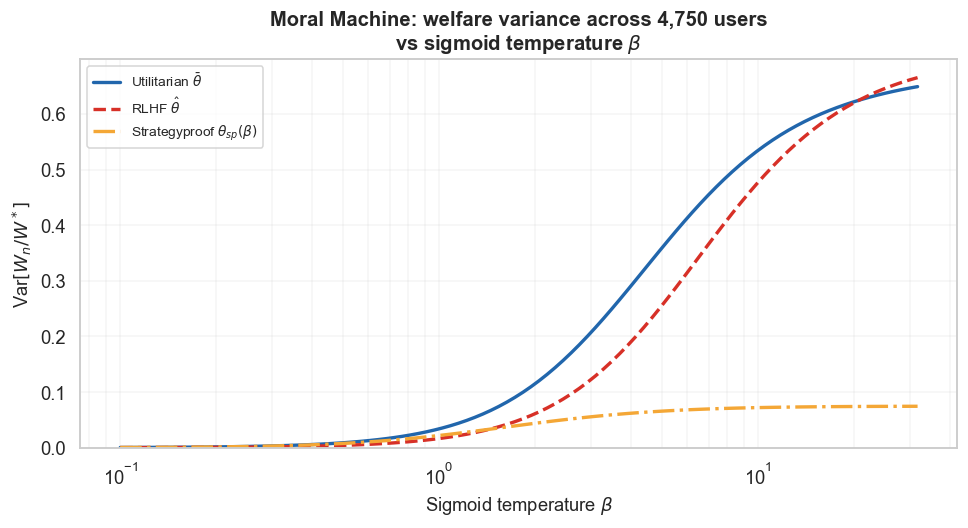

Utilitarian     β=0.1: 0.0004   β=1: 0.0354   β=32: 0.6492
RLHF            β=0.1: 0.0002   β=1: 0.0172   β=32: 0.6654
SP              β=0.1: 0.0004   β=1: 0.0226   β=32: 0.0745


In [22]:
# ── Welfare variance across agents vs β — Moral Machine ──────────────────

from scipy.special import expit
from scipy.optimize import minimize

theta_arr    = profiles.astype(float)
N_agents     = len(theta_arr)
w_uniform    = np.ones(N_agents) / N_agents
theta_bar_m  = theta_bar.astype(float)
theta_rlhf_m = theta_hat.astype(float)
alpha_q      = make_uniform_qdep().astype(float)

def phi_all(theta_agents, beta, alpha):
    logits = alpha @ theta_agents.T
    factor = (expit(beta * logits) - 0.5)
    return factor.T @ alpha / len(alpha)

def phi_inv(target, beta, alpha, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])
    def loss_and_grad(theta):
        s        = expit(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * np.dot(residual, residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    return res.x

def per_agent_welfare(theta_deploy, beta, theta_agents, alpha):
    factor = (expit(beta * (alpha @ theta_deploy)) - 0.5)
    return (alpha @ theta_agents.T * factor[:, None]).mean(axis=0)

psi_star_m = (np.sign(alpha_q @ theta_bar_m)[:, None] * alpha_q).mean(axis=0)
W_star_m   = float(theta_bar_m @ psi_star_m)
betas      = np.logspace(-1, 1.5, 100)

var_util, var_rlhf, var_sp = [], [], []
theta_sp_prev = theta_bar_m.copy()

for b in betas:
    phi_avg       = phi_all(theta_arr, b, alpha_q).mean(axis=0)
    theta_sp      = phi_inv(phi_avg, b, alpha_q, theta_init=theta_sp_prev)
    theta_sp_prev = theta_sp.copy()

    W_util = per_agent_welfare(theta_bar_m,  b, theta_arr, alpha_q)
    W_rlhf = per_agent_welfare(theta_rlhf_m, b, theta_arr, alpha_q)
    W_sp   = per_agent_welfare(theta_sp,     b, theta_arr, alpha_q)

    W_star_sq = W_star_m ** 2
    var_util.append(W_util.var() / W_star_sq)
    var_rlhf.append(W_rlhf.var() / W_star_sq)
    var_sp.append(  W_sp.var()   / W_star_sq)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(betas, var_util, color='#2166ac', lw=2.2, ls='-',
        label=r'Utilitarian $\bar\theta$')
ax.plot(betas, var_rlhf, color='#d73027', lw=2.2, ls='--',
        label=r'RLHF $\hat\theta$')
ax.plot(betas, var_sp,   color='#f4a736', lw=2.2, ls='-.',
        label=r'Strategyproof $\theta_{sp}(\beta)$')
ax.set_xscale('log')
ax.set_ylim(bottom=0)
ax.set_xlabel(r'Sigmoid temperature $\beta$', fontsize=12)
ax.set_ylabel(r'Var$[W_n / W^*]$', fontsize=12)
ax.set_title(f'Moral Machine: welfare variance across {N_agents:,} users\n'
             r'vs sigmoid temperature $\beta$', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.show()

for lbl, arr in [('Utilitarian', var_util), ('RLHF', var_rlhf), ('SP', var_sp)]:
    print(f'{lbl:14s}  β=0.1: {arr[0]:.4f}   β=1: {arr[np.argmin(np.abs(betas-1))]:.4f}'
          f'   β=32: {arr[-1]:.4f}')
